In [66]:
import sys, os, pickle, gzip, pathlib, math, warnings
import numpy as np
import pandas as pd
from scipy import stats, optimize
from scipy.interpolate import PchipInterpolator, interp1d
from scipy.stats import median_abs_deviation as mad
from astropy.cosmology import FlatLambdaCDM, LambdaCDM, z_at_value
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import IntegrationWarning

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=IntegrationWarning)

mpl.rcParams.update({
    "font.family": "serif", "font.size": 11,
    "axes.labelsize": 12, "axes.titlesize": 13,
    "legend.fontsize": 9, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "lines.linewidth": 1.5, "axes.grid": True, "grid.alpha": 0.3,
})

DATA = pathlib.Path("..") / "data"
sys.path.insert(0, str(pathlib.Path("..").resolve()))

C_U3 = "#2ca02c"
C_DES = "#ff7f0e"
C_PAN = "#1f77b4"

print("Setup complete.")


Setup complete.


In [ ]:
with gzip.open(DATA / "analysis/hubble_data.pklz", "rb") as f:
    d = pickle.load(f)

hd = d["hd"]
xd = d["xd"]
z_nodes = d["z_nodes"]
mu_binned = d["mu_binned"]
mu_binned_err = d["mu_binned_err"]
des_records = d["des_records"]
pan_dedup = d["pan_dedup"]
cosmo = d["cosmo"]
per_survey_results = d["per_survey_results"]
alpha_fit = d["alpha_fit"]
beta_fit = d["beta_fit"]
uid_union3 = d["uid_union3"]
u3_mB = d["u3_mB"]
u3_x1 = d["u3_x1"]
u3_c = d["u3_c"]
u3_z = d["u3_z"]
p_high_mass = d["p_high_mass"]
mu_uni_per_sn = d["mu_uni_per_sn"]

# Union3 compressed likelihood (FITS)
from scripts.common import read_fits_2d
mu_fits = read_fits_2d(str(DATA / "union3/union3_release/mu_mat_union3_cosmo=2_mu.fits"))
icov_u3 = mu_fits[1:, 1:]
cov_u3 = np.linalg.inv(icov_u3)

# Union3 raw data for Tripp reconstruction
u3_pickle = list((DATA / "union3/union3_release").glob("*.pickle"))
with gzip.open(str(u3_pickle[0]), "rb") as f:
    sn_data, metadata, config = pickle.load(f)

print(f"Loaded: {len(hd)} SNe total")
for s in ["Union3", "DES", "Pantheon+"]:
    n = (hd["survey"] == s).sum()
    print(f"  {s}: {n}")
print(f"Crossmatch pairs: {len(xd)}")
pairs = sorted(xd["pair"].unique())
for pt in pairs:
    print(f"  {pt}: {(xd['pair']==pt).sum()}")


Loaded: 5450 SNe total
  Union3: 2087
  DES: 1820
  Pantheon+: 1543
Crossmatch pairs: 2035
  DES_vs_Pantheon+: 341
  DES_vs_Union3: 343
  Pantheon+_vs_Union3: 1351
dict_keys(['hd', 'z_nodes', 'mu_binned', 'mu_binned_err', 'alpha_fit', 'beta_fit', 'M_Union3', 'M_DES', 'M_Pantheon+', 'des_records', 'mu_uni_per_sn', 'uid_union3', 'pan_dedup', 'cosmo', 'per_survey_results', 'all_matches', 'u3_mB', 'u3_x1', 'u3_c', 'u3_z', 'xd', 'p_high_mass', 'pan_host'])


## Section 1: Dataset Summary

In [68]:
print("=" * 65)
print("DATASET OVERVIEW")
print("=" * 65)
print(f"  {'Survey':12s} {'N_SNe':>8s} {'z_min':>8s} {'z_max':>8s} {'<z>':>8s}")
print("  " + "-" * 44)
for surv in ["Union3", "DES", "Pantheon+"]:
    sub = hd[hd["survey"] == surv]
    print(f"  {surv:<12s} {len(sub):>8d} {sub['z'].min():>8.4f} {sub['z'].max():>8.4f} {sub['z'].mean():>8.4f}")
print()

print("CROSSMATCH OVERLAP")
print("=" * 65)
print(f"  {'Pair':28s} {'N_matches':>10s}")
print("  " + "-" * 38)
for pt in sorted(xd["pair"].unique()):
    n = (xd["pair"] == pt).sum()
    print(f"  {pt.replace('_', ' '):28s} {n:>10d}")


DATASET OVERVIEW
  Survey          N_SNe    z_min    z_max      <z>
  --------------------------------------------
  Union3           2087   0.0093   2.2600   0.2845
  DES              1820   0.0251   1.1442   0.4675
  Pantheon+        1543   0.0012   2.2614   0.2418

CROSSMATCH OVERLAP
  Pair                          N_matches
  --------------------------------------
  DES vs Pantheon+                    341
  DES vs Union3                       343
  Pantheon+ vs Union3                1351


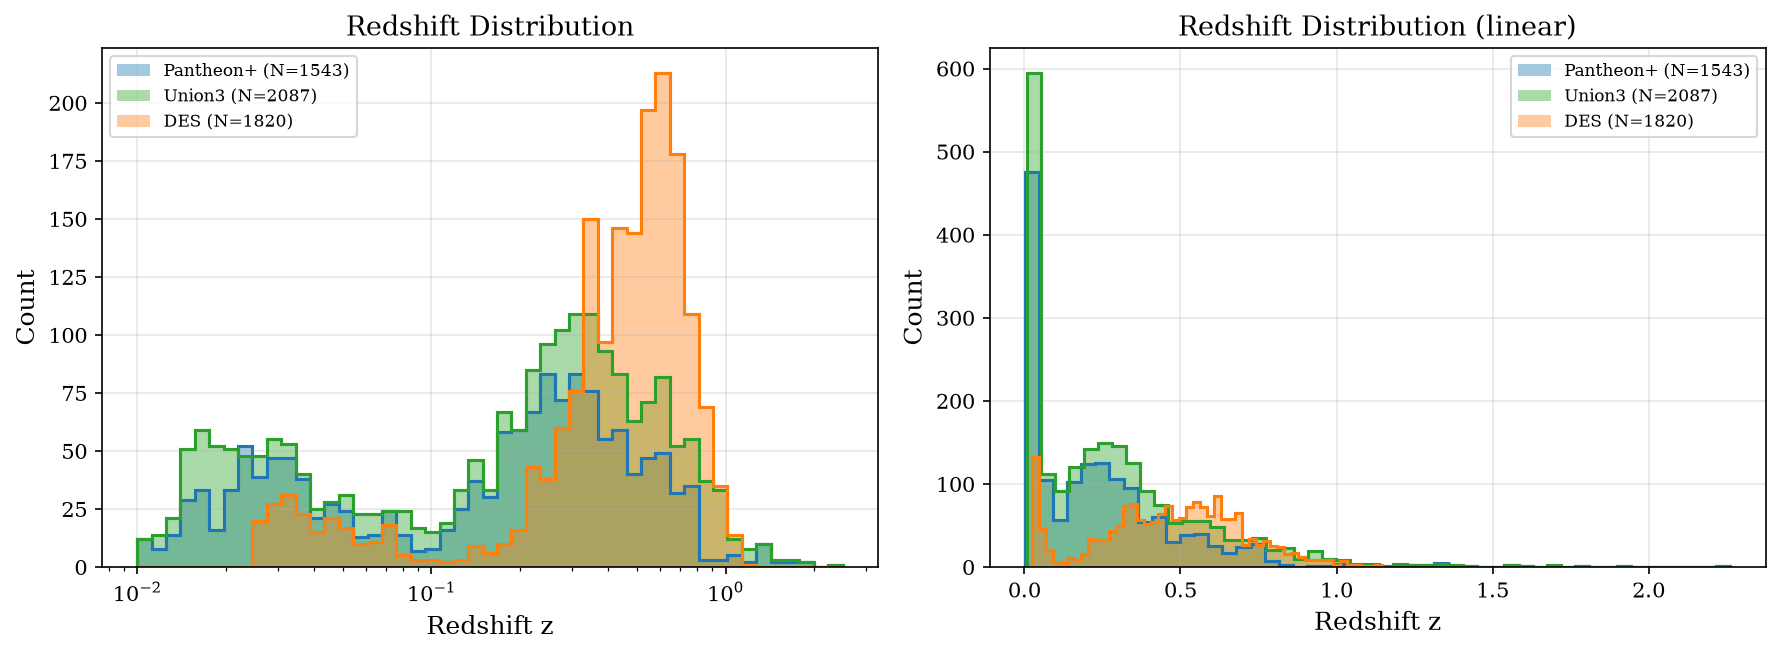

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
bins = np.logspace(np.log10(0.01), np.log10(2.5), 50)
for surv, c in [("Pantheon+", C_PAN), ("Union3", C_U3), ("DES", C_DES)]:
    sub = hd[hd["survey"] == surv]["z"].dropna()
    ax.hist(sub, bins=bins, histtype="stepfilled", alpha=0.4,
            color=c, label=f"{surv} (N={len(sub)})", density=False)
    ax.hist(sub, bins=bins, histtype="step", color=c, lw=1.5, density=False)
ax.set_xscale("log")
ax.set_xlabel("Redshift z")
ax.set_ylabel("Count")
ax.set_title("Redshift Distribution")
ax.legend(fontsize=8)

ax = axes[1]
for surv, c in [("Pantheon+", C_PAN), ("Union3", C_U3), ("DES", C_DES)]:
    sub = hd[hd["survey"] == surv]["z"].dropna()
    ax.hist(sub, bins=50, histtype="stepfilled", alpha=0.4,
            color=c, label=f"{surv} (N={len(sub)})", density=False)
    ax.hist(sub, bins=50, histtype="step", color=c, lw=1.5, density=False)
ax.set_xlabel("Redshift z")
ax.set_ylabel("Count")
ax.set_title("Redshift Distribution (linear)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Section 2: Crossmatched SN Comparison

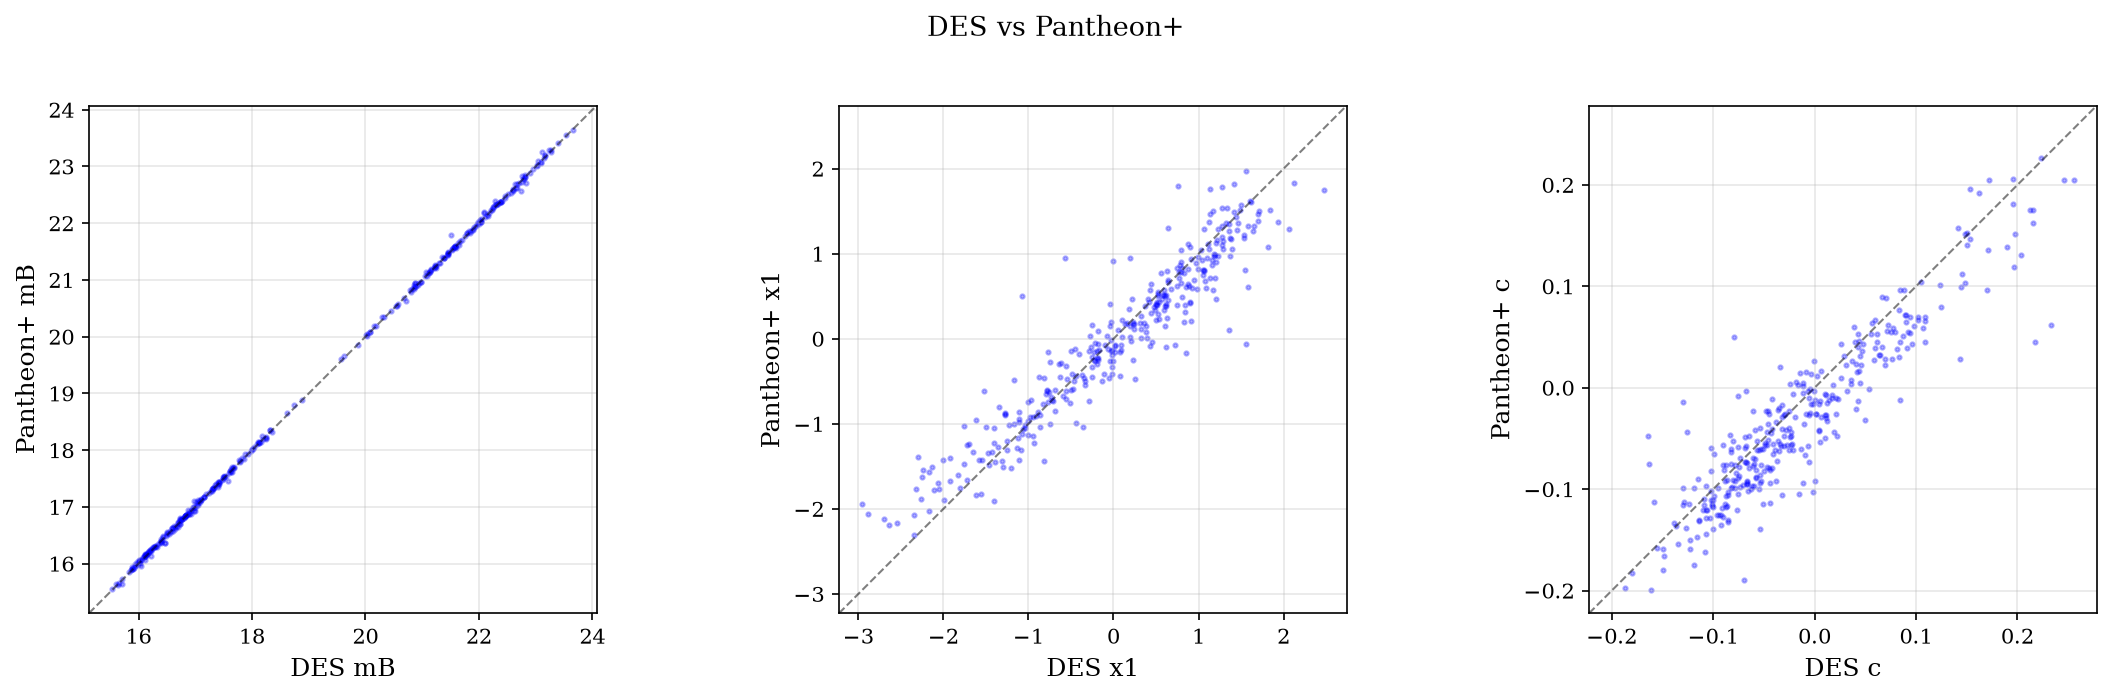

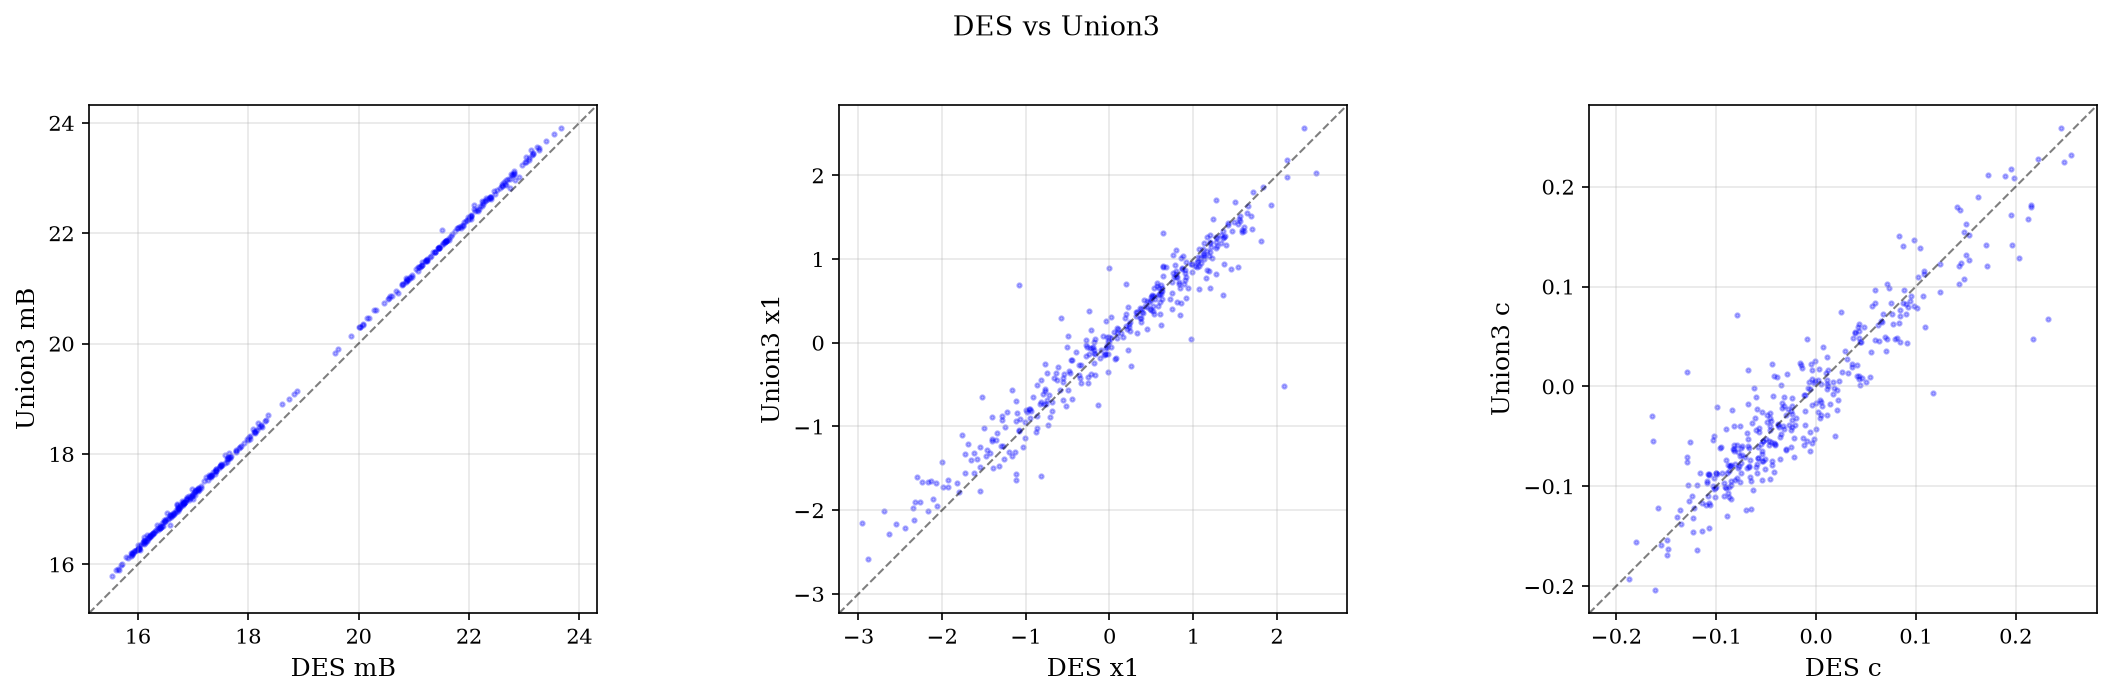

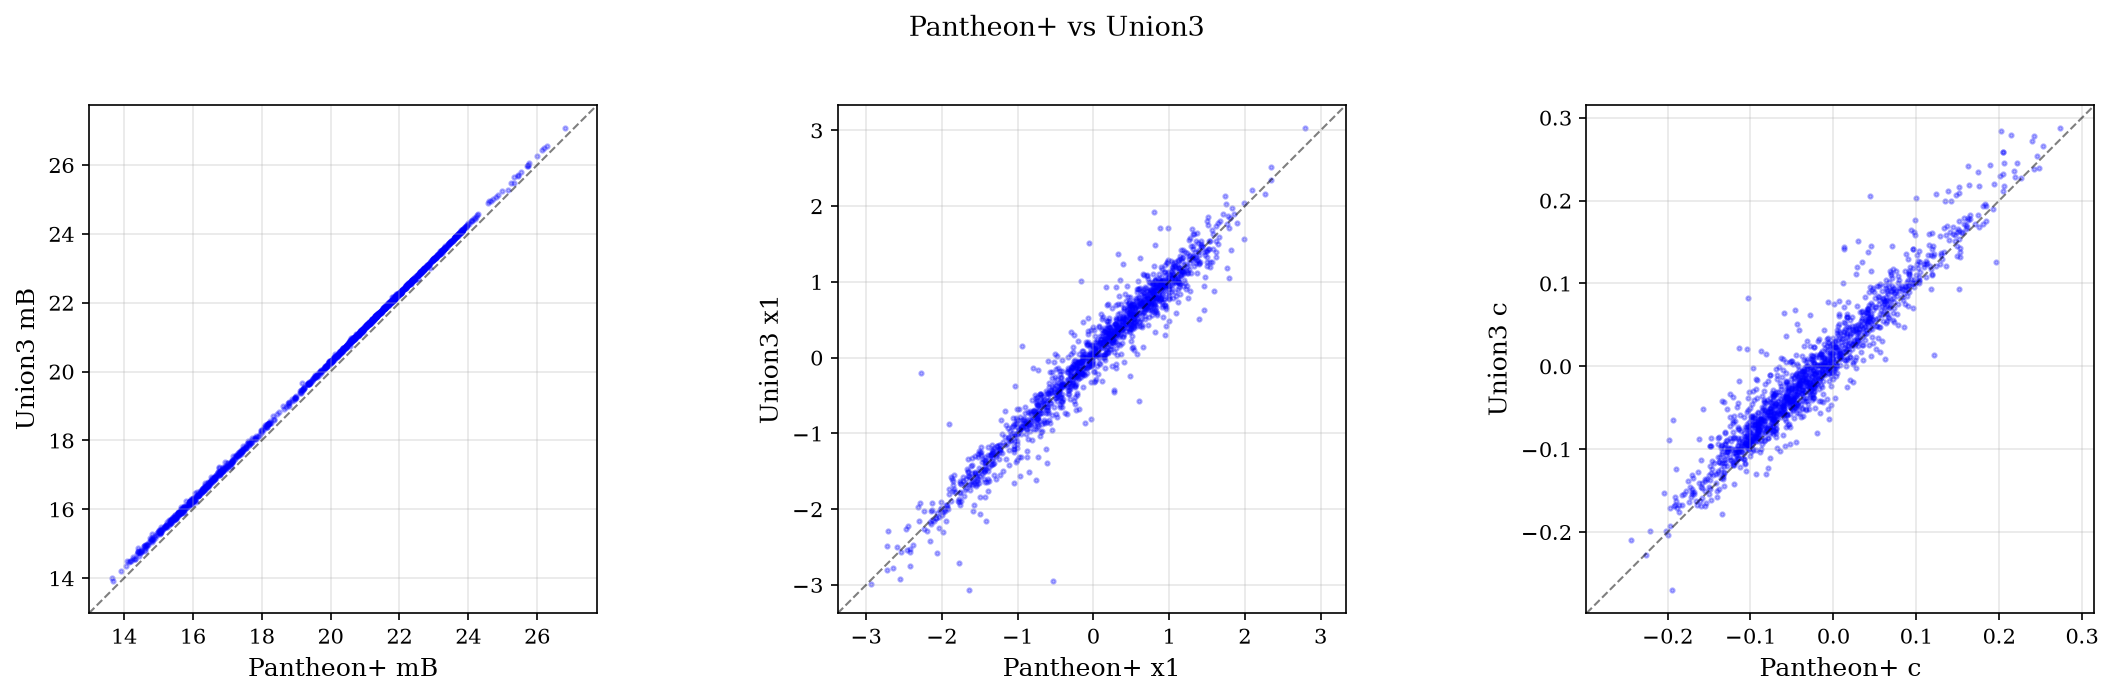

In [98]:
PAIR_LABELS = {
    "Pantheon+_vs_Union3": "Pantheon+ vs Union3",
    "DES_vs_Union3": "DES vs Union3",
    "DES_vs_Pantheon+": "DES vs Pantheon+",
}

# Scatter plots: mB, x1, c for each pair
for pt in sorted(xd["pair"].unique()):
    sub = xd[xd["pair"] == pt].dropna(subset=["mB_a", "mB_b", "x1_a", "x1_b", "c_a", "c_b"])
    label = PAIR_LABELS[pt]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, param_a, param_b, xlabel, ylabel in [
        (axes[0], "mB_a", "mB_b", f"{label.split(' vs ')[0]} mB", f"{label.split(' vs ')[1]} mB"),
        (axes[1], "x1_a", "x1_b", f"{label.split(' vs ')[0]} x1", f"{label.split(' vs ')[1]} x1"),
        (axes[2], "c_a", "c_b", f"{label.split(' vs ')[0]} c", f"{label.split(' vs ')[1]} c"),
    ]:
        a_vals = sub[param_a].values
        b_vals = sub[param_b].values
        lim = [min(a_vals.min(), b_vals.min()), max(a_vals.max(), b_vals.max())]
        pad = 0.05 * (lim[1] - lim[0])
        lim = [lim[0] - pad, lim[1] + pad]
        ax.scatter(a_vals, b_vals, s=4, alpha=0.3, color="blue", rasterized=True)
        ax.plot(lim, lim, "k--", lw=1, alpha=0.5)
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_aspect("equal")

    fig.suptitle(label, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


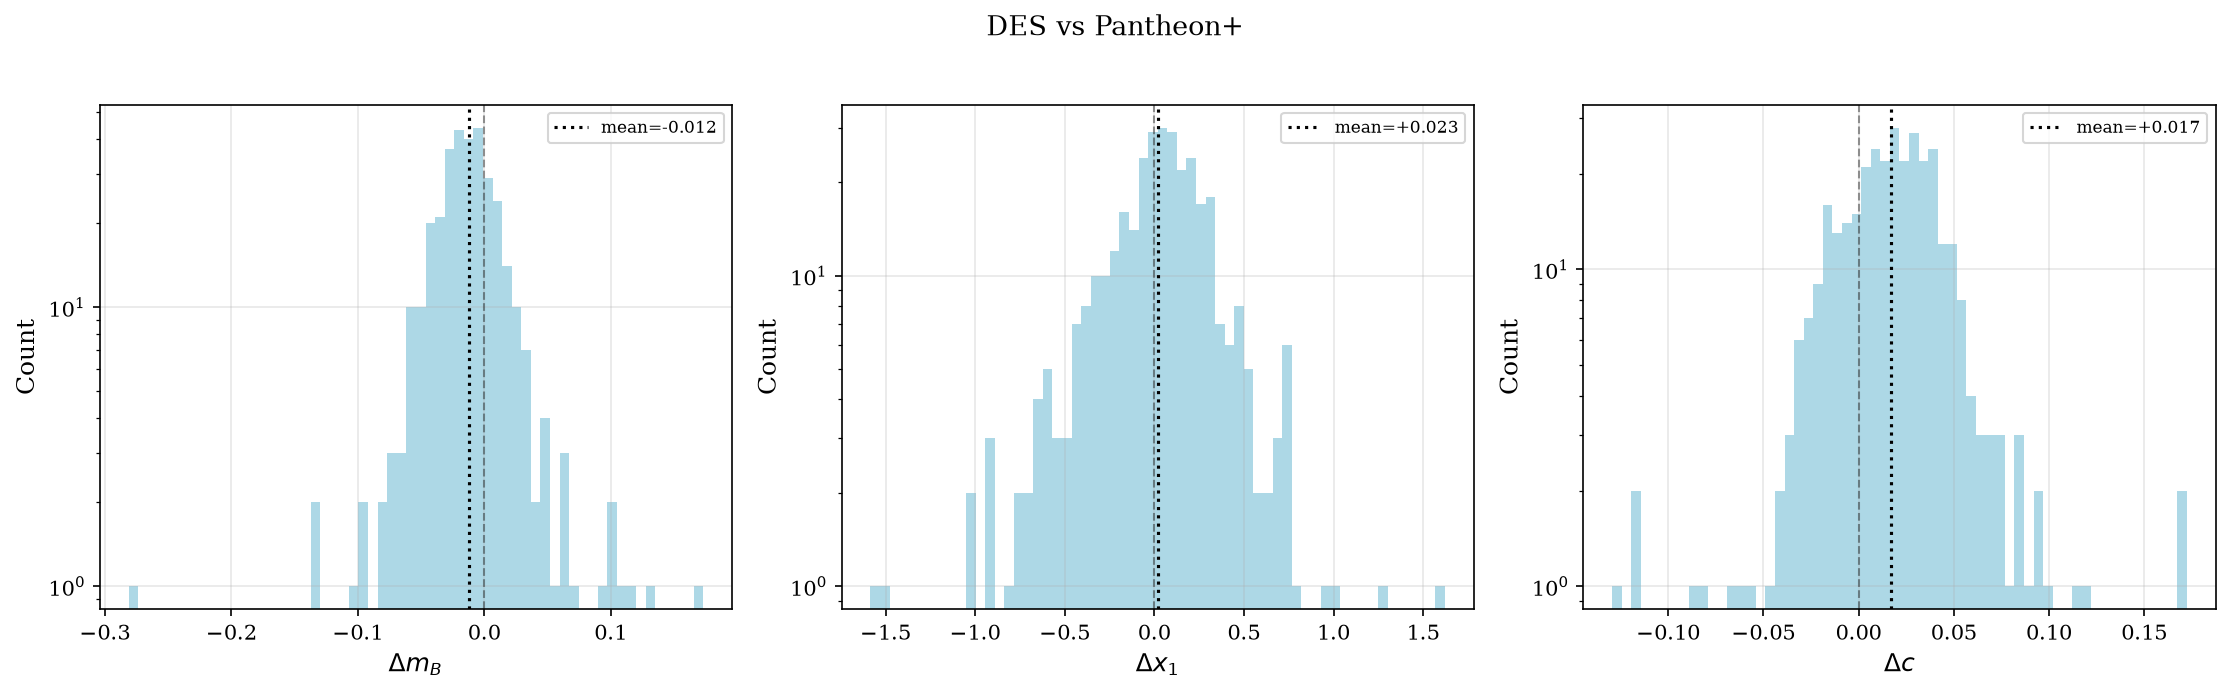

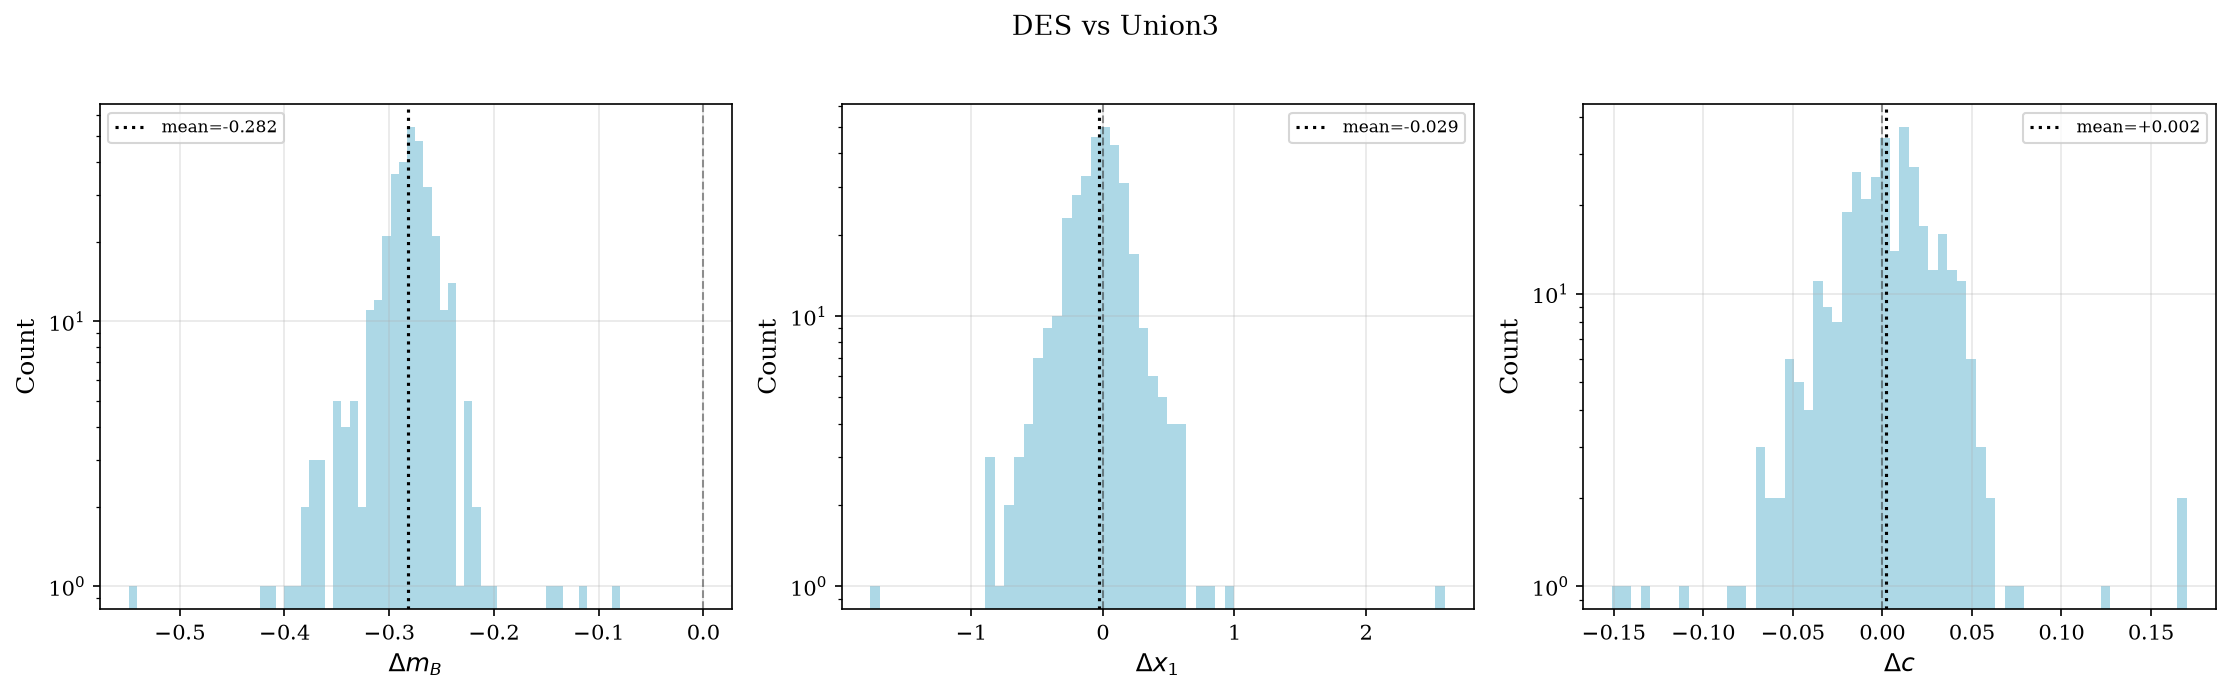

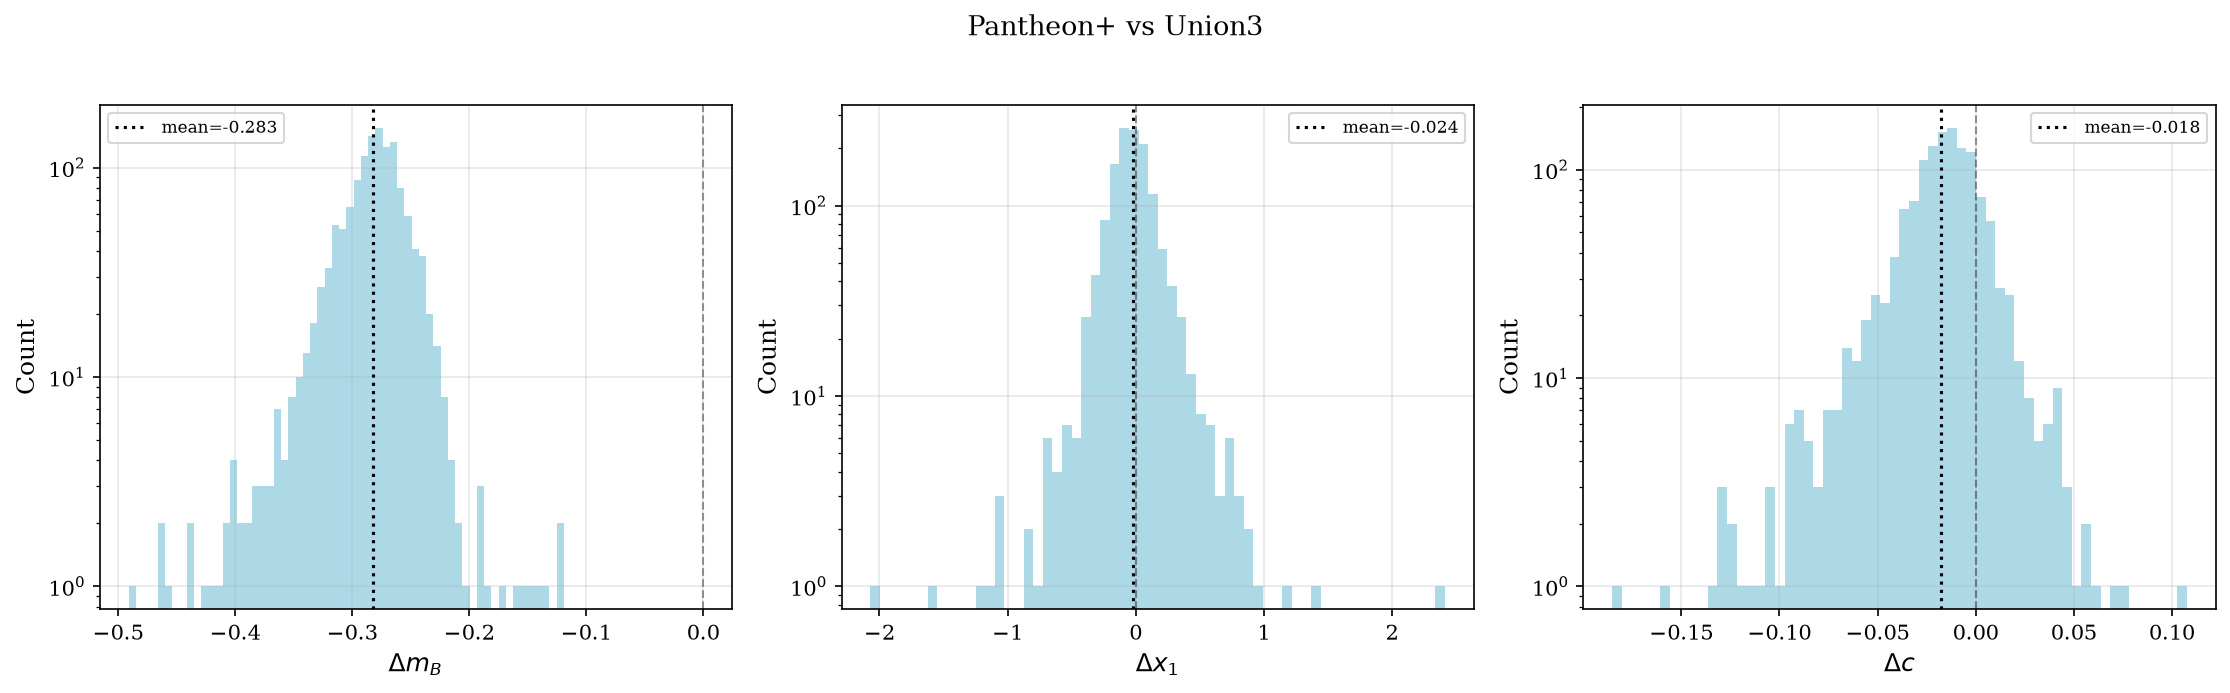

In [108]:
# Histograms of differences for each pair
for pt in sorted(xd["pair"].unique()):
    sub = xd[xd["pair"] == pt].dropna(subset=["dmB", "dx1", "dc"])
    label = PAIR_LABELS[pt]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, param, xlabel in [
        (axes[0], "dmB", r"$\Delta m_B$"),
        (axes[1], "dx1", r"$\Delta x_1$"),
        (axes[2], "dc", r"$\Delta c$"),
    ]:
        v = sub[param].values
        ax.hist(v, bins=60, color="lightblue", alpha=1, edgecolor="none")
        ax.axvline(0, color="k", ls="--", lw=1, alpha=0.4)
        ax.axvline(np.mean(v), color="k", ls=":", lw=1.5,
                   label=f"mean={np.mean(v):+.3f}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")
        ax.set_yscale('log')
        ax.legend(fontsize=8)

    fig.suptitle(label, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


In [72]:
print("CROSSMATCH STATISTICS")
print("=" * 65)
header = f"  {'Pair':28s} {'Param':6s} {'N':>6s} {'mean':>9s} {'median':>9s} {'std':>8s} {'MAD':>8s}"
print(header)
print("  " + "-" * 73)
for pt in sorted(xd["pair"].unique()):
    sub = xd[xd["pair"] == pt]
    plabel = pt.replace("_", " ")
    for param in ["dmB", "dx1", "dc"]:
        v = sub[param].dropna().values
        n = len(v)
        mn = np.mean(v)
        med = np.median(v)
        sd = np.std(v)
        mdv = mad(v)
        print(f"  {plabel:28s} {param:6s} {n:>6d} {mn:>+9.4f} {med:>+9.4f} {sd:>8.4f} {mdv:>8.4f}")
    print()


CROSSMATCH STATISTICS
  Pair                         Param       N      mean    median      std      MAD
  -------------------------------------------------------------------------
  DES vs Pantheon+             dmB       341   -0.0122   -0.0127   0.0367   0.0165
  DES vs Pantheon+             dx1       341   +0.0227   +0.0484   0.3663   0.1860
  DES vs Pantheon+             dc        341   +0.0170   +0.0174   0.0341   0.0191

  DES vs Union3                dmB       343   -0.2823   -0.2785   0.0385   0.0142
  DES vs Union3                dx1       343   -0.0292   -0.0169   0.3131   0.1453
  DES vs Union3                dc        343   +0.0023   +0.0029   0.0339   0.0170

  Pantheon+ vs Union3          dmB      1351   -0.2826   -0.2795   0.0339   0.0162
  Pantheon+ vs Union3          dx1      1351   -0.0240   -0.0309   0.2405   0.1035
  Pantheon+ vs Union3          dc       1351   -0.0179   -0.0155   0.0253   0.0118



## Section 3: Per-Survey Tripp Standardization

In [73]:
cosmo_ref = FlatLambdaCDM(H0=70, Om0=0.3)

fits = {}
for surv in ["Pantheon+", "Union3", "DES"]:
    sub = hd[hd["survey"] == surv].dropna(subset=["mB", "x1", "c", "z"])
    n = len(sub)
    mu_model = cosmo_ref.distmod(sub["z"].values).value
    Y = sub["mB"].values - mu_model
    X = np.column_stack([np.ones(n), -sub["x1"].values, sub["c"].values])
    coeffs, resid, rank, s = np.linalg.lstsq(X, Y, rcond=None)
    M, alpha, beta = coeffs
    residual = Y - X @ coeffs
    resid_std = np.std(residual)
    fits[surv] = {"M": M, "alpha": alpha, "beta": beta, "resid_std": resid_std, "n": n}

print("PER-SURVEY TRIPP FITS")
print("=" * 65)
print(f"  {'Survey':12s} {'M':>9s} {'alpha':>8s} {'beta':>8s} {'std_resid':>10s} {'N':>6s}")
print("  " + "-" * 52)
for surv in ["Pantheon+", "Union3", "DES"]:
    r = fits[surv]
    print(f"  {surv:<12s} {r['M']:>+9.4f} {r['alpha']:>+8.4f} {r['beta']:>+8.4f} {r['resid_std']:>10.4f} {r['n']:>6d}")


PER-SURVEY TRIPP FITS
  Survey               M    alpha     beta  std_resid      N
  ----------------------------------------------------
  Pantheon+     -19.3190  +0.1383  +2.5703     0.1824   1543
  Union3        -19.0661  +0.1180  +2.5248     0.2356   2087
  DES           -19.3546  +0.1135  +2.1103     0.2919   1820


In [74]:
cosmo_ref = LambdaCDM(H0=70, Om0=0.2858, Ode0=0.5998)
#  0.2858   0.5998 
fits = {}
for surv in ["Pantheon+", "Union3", "DES"]:
    sub = hd[hd["survey"] == surv].dropna(subset=["mB", "x1", "c", "z"])
    n = len(sub)
    mu_model = cosmo_ref.distmod(sub["z"].values).value
    Y = sub["mB"].values - mu_model
    X = np.column_stack([np.ones(n), -sub["x1"].values, sub["c"].values])
    coeffs, resid, rank, s = np.linalg.lstsq(X, Y, rcond=None)
    M, alpha, beta = coeffs
    residual = Y - X @ coeffs
    resid_std = np.std(residual)
    fits[surv] = {"M": M, "alpha": alpha, "beta": beta, "resid_std": resid_std, "n": n}

print("PER-SURVEY TRIPP FITS")
print("=" * 65)
print(f"  {'Survey':12s} {'M':>9s} {'alpha':>8s} {'beta':>8s} {'std_resid':>10s} {'N':>6s}")
print("  " + "-" * 52)
for surv in ["Pantheon+", "Union3", "DES"]:
    r = fits[surv]
    print(f"  {surv:<12s} {r['M']:>+9.4f} {r['alpha']:>+8.4f} {r['beta']:>+8.4f} {r['resid_std']:>10.4f} {r['n']:>6d}")


PER-SURVEY TRIPP FITS
  Survey               M    alpha     beta  std_resid      N
  ----------------------------------------------------
  Pantheon+     -19.3042  +0.1361  +2.5495     0.1811   1543
  Union3        -19.0494  +0.1164  +2.5031     0.2336   2087
  DES           -19.3290  +0.1138  +2.1046     0.2912   1820


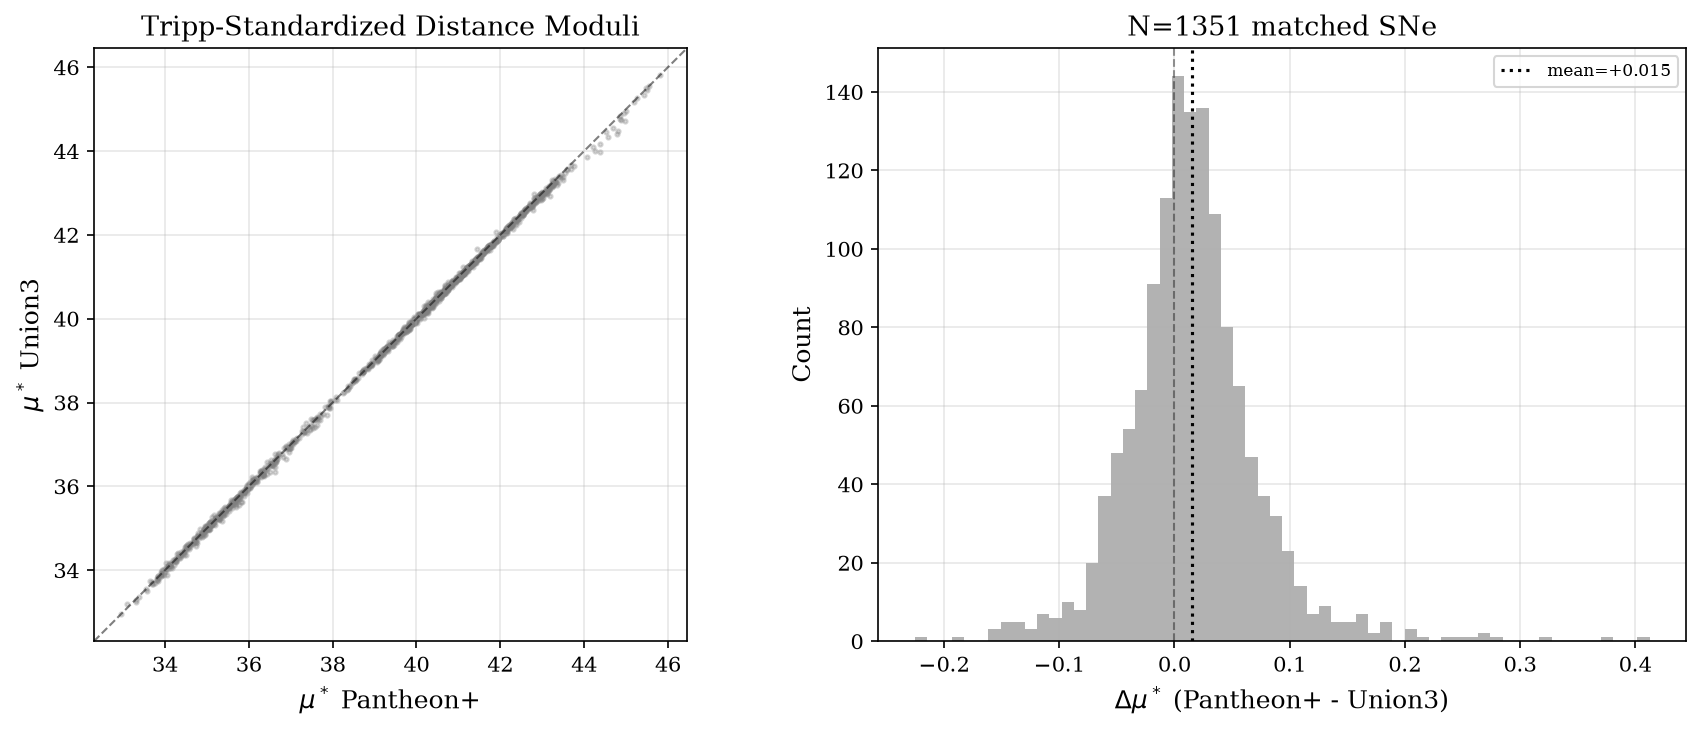

MATCHED TRIPP-STANDARDIZED DISTANCES
  N = 1351
  <dmu*> = +0.0152
  median = +0.0122
  std    = 0.0575
  MAD    = 0.0285

Comparison with raw dmB from Section 2:
  <dmB>    = -0.2826 (raw SALT2 offset)
  <dmu*>   = +0.0152 (after Tripp standardization)
  delta    = -0.2978 (change due to standardization)


In [75]:
# Apply to matched Pantheon+ vs Union3 SNe
pair = xd[xd["pair"] == "Pantheon+_vs_Union3"].copy()

pair["mu_star_pan"] = (pair["mB_a"] - fits["Pantheon+"]["M"]
                       + fits["Pantheon+"]["alpha"] * pair["x1_a"]
                       - fits["Pantheon+"]["beta"] * pair["c_a"])

pair["mu_star_u3"] = (pair["mB_b"] - fits["Union3"]["M"]
                      + fits["Union3"]["alpha"] * pair["x1_b"]
                      - fits["Union3"]["beta"] * pair["c_b"])

pair["dmu_star"] = pair["mu_star_pan"] - pair["mu_star_u3"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.scatter(pair["mu_star_pan"], pair["mu_star_u3"], s=4, alpha=0.3, color="gray", rasterized=True)
lim = [min(pair["mu_star_pan"].min(), pair["mu_star_u3"].min()),
       max(pair["mu_star_pan"].max(), pair["mu_star_u3"].max())]
pad = 0.05 * (lim[1] - lim[0]); lim = [lim[0] - pad, lim[1] + pad]
ax.plot(lim, lim, "k--", lw=1, alpha=0.5)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel(r"$\mu^*$ Pantheon+")
ax.set_ylabel(r"$\mu^*$ Union3")
ax.set_title("Tripp-Standardized Distance Moduli")
ax.set_aspect("equal")

ax = axes[1]
v = pair["dmu_star"].values
ax.hist(v, bins=60, color="gray", alpha=0.6, edgecolor="none")
ax.axvline(0, color="k", ls="--", lw=1, alpha=0.4)
ax.axvline(np.mean(v), color="k", ls=":", lw=1.5, label=f"mean={np.mean(v):+.3f}")
ax.set_xlabel(r"$\Delta\mu^*$ (Pantheon+ - Union3)")
ax.set_ylabel("Count")
ax.legend(fontsize=8)
ax.set_title(f"N={len(v)} matched SNe")

plt.tight_layout()
plt.show()

print("MATCHED TRIPP-STANDARDIZED DISTANCES")
print("=" * 60)
print(f"  N = {len(v)}")
print(f"  <dmu*> = {np.mean(v):+.4f}")
print(f"  median = {np.median(v):+.4f}")
print(f"  std    = {np.std(v):.4f}")
print(f"  MAD    = {mad(v):.4f}")
print()
print("Comparison with raw dmB from Section 2:")
dmB = pair["dmB"].values
print(f"  <dmB>    = {np.mean(dmB):+.4f} (raw SALT2 offset)")
print(f"  <dmu*>   = {np.mean(v):+.4f} (after Tripp standardization)")
print(f"  delta    = {np.mean(dmB) - np.mean(v):+.4f} (change due to standardization)")


## Section 4: Published Distance Products

In [76]:
# Bin DES and Pantheon+ to 22 Union3 nodes via PCHIP
def interp_at_nodes(z_nodes, df, mu_col, z_col="z"):
    x = df[z_col].values.astype(float)
    y = df[mu_col].values.astype(float)
    df_agg = pd.DataFrame({z_col: x, mu_col: y}).groupby(z_col, as_index=False).mean()
    f = PchipInterpolator(df_agg[z_col].values, df_agg[mu_col].values, extrapolate=False)
    y_nodes = f(z_nodes)
    return y_nodes

des_mu_raw = des_records[["z", "MU"]].dropna()
mu_des = interp_at_nodes(z_nodes, des_mu_raw, "MU")

pan_mu_raw = pan_dedup[["zHD", "MU_SH0ES"]].dropna().rename(columns={"zHD": "z"})
mu_pan = interp_at_nodes(z_nodes, pan_mu_raw, "MU_SH0ES")

print("BINNED DISTANCE MODULI AT 22 UNION3 Z-NODES")
print("=" * 60)
print(f"  {'z':>6s}  {'U3_mu':>7s}  {'DES_mu':>7s}  {'Pan_mu':>7s}")
print("  " + "-" * 33)
for i in range(len(z_nodes)):
    print(f"  {z_nodes[i]:>6.3f}  {mu_binned[i]:>7.3f}  {mu_des[i]:>7.3f}  {mu_pan[i]:>7.3f}")


BINNED DISTANCE MODULI AT 22 UNION3 Z-NODES
       z    U3_mu   DES_mu   Pan_mu
  ---------------------------------
   0.050   36.630   36.762   36.482
   0.100   38.235   38.331   38.419
   0.150   39.148   39.202   39.107
   0.200   39.835   39.824   39.856
   0.250   40.340   40.371   40.530
   0.300   40.814   41.137   40.938
   0.350   41.202   41.341   41.259
   0.400   41.569   41.559   41.595
   0.450   41.823   41.931   41.758
   0.500   42.136   42.521   42.246
   0.550   42.352   42.684   42.289
   0.600   42.600   42.857   42.585
   0.650   42.793   42.822   42.791
   0.700   42.945   43.401   43.109
   0.750   43.125   43.158   43.045
   0.800   43.320   43.539   43.433
   0.898   43.648   44.018   43.571
   0.996   44.011   44.054   44.114
   1.094   44.191   44.457   44.435
   1.232   44.578      nan   44.321
   1.391   44.842      nan   44.794
   2.262   45.997      nan      nan


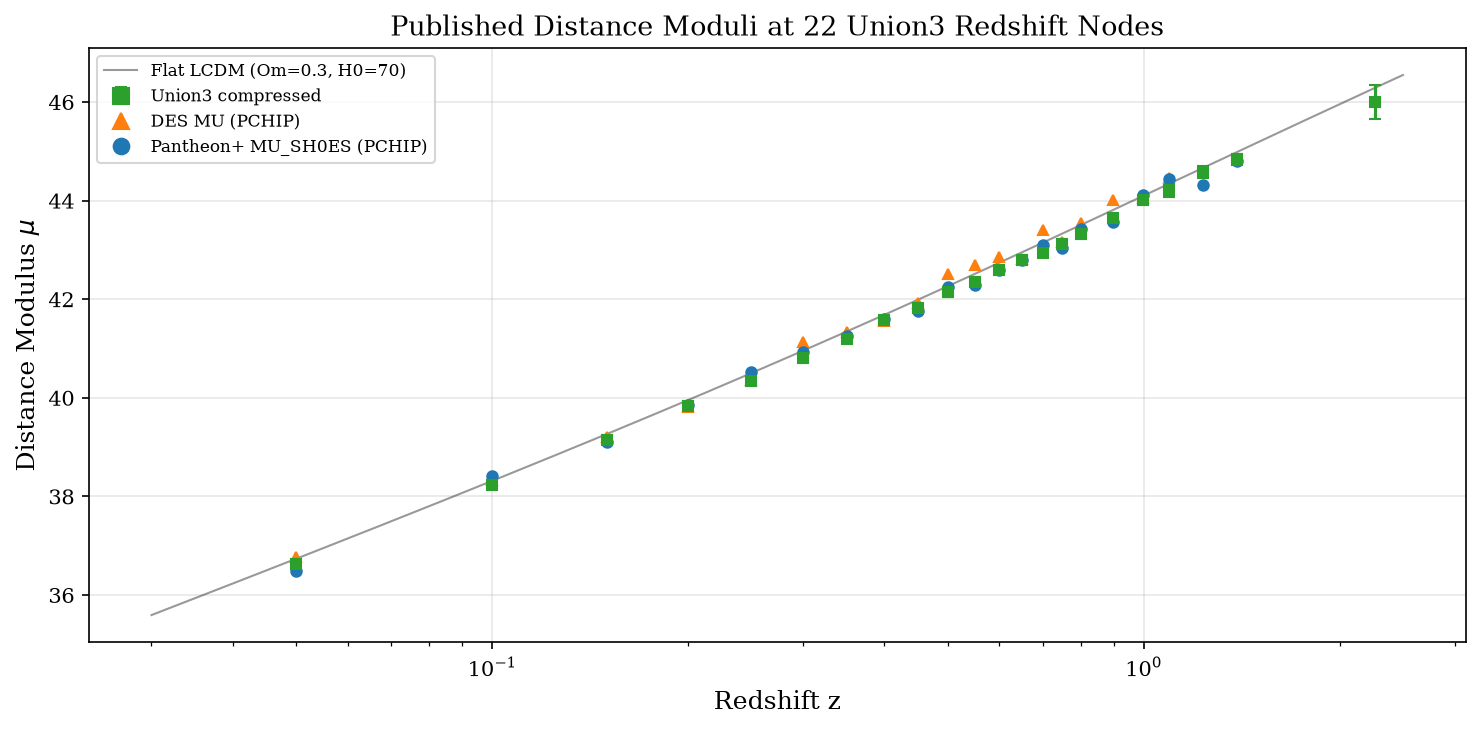

In [77]:
# mu(z) comparison
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(z_nodes, mu_binned, yerr=mu_binned_err, fmt="s", color=C_U3,
            ms=5, capsize=3, label="Union3 compressed", zorder=5)
ax.errorbar(z_nodes, mu_des, fmt="^", color=C_DES, ms=5, capsize=3,
            label="DES MU (PCHIP)", zorder=4)
ax.errorbar(z_nodes, mu_pan, fmt="o", color=C_PAN, ms=5, capsize=3,
            label="Pantheon+ MU_SH0ES (PCHIP)", zorder=4)
z_curve = np.logspace(np.log10(0.03), np.log10(2.5), 300)
mu_lcdm = cosmo.distmod(z_curve).value
ax.plot(z_curve, mu_lcdm, "k-", lw=1, alpha=0.4, label="Flat LCDM (Om=0.3, H0=70)")
ax.set_xscale("log")
ax.set_xlabel("Redshift z")
ax.set_ylabel(r"Distance Modulus $\mu$")
ax.set_title("Published Distance Moduli at 22 Union3 Redshift Nodes")
ax.legend(fontsize=8, markerscale=1.5)
plt.tight_layout()
plt.show()


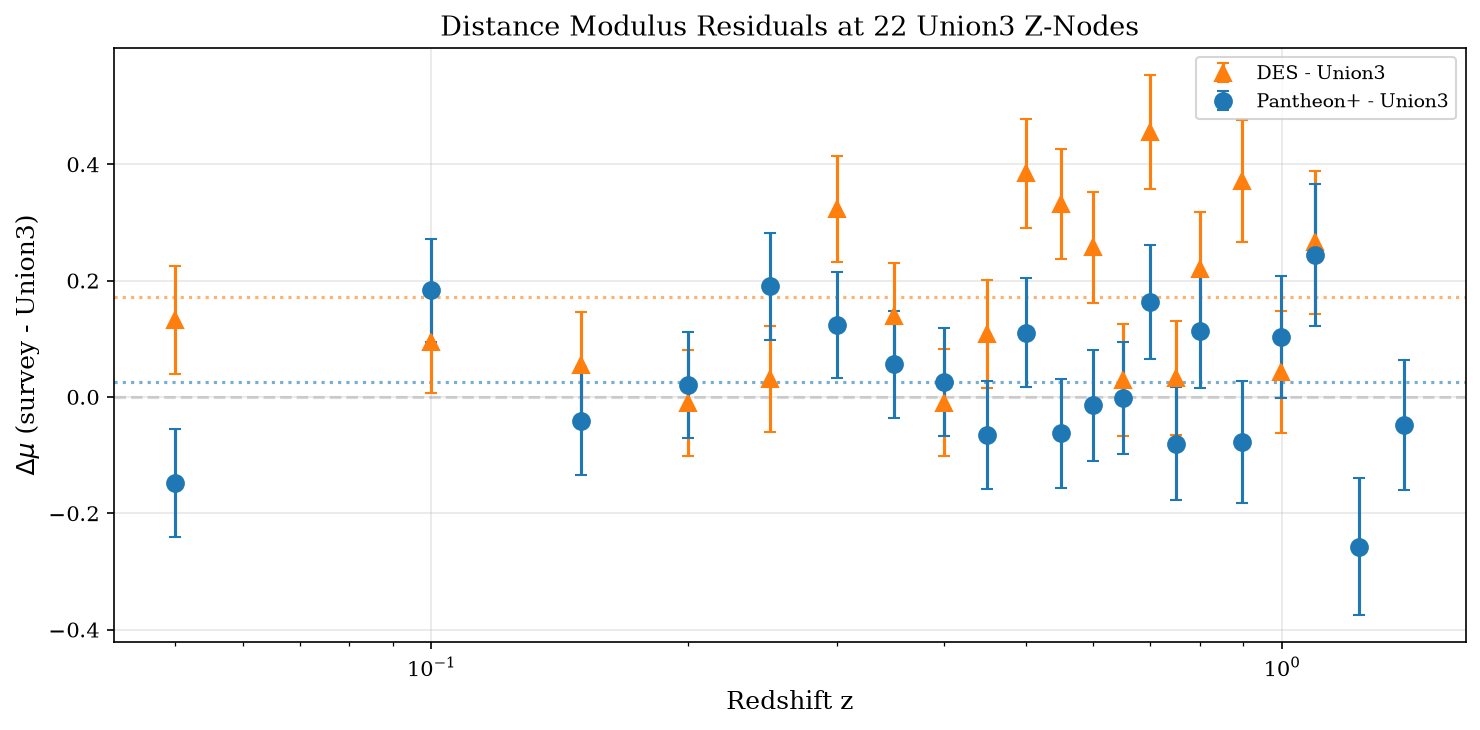

OFFSET STATISTICS (22 nodes)
  DES - Union3             : mean = +0.1711 +/- 0.1454 mag  (N=19)
  Pantheon+ - Union3       : mean = +0.0256 +/- 0.1216 mag  (N=21)
  DES - Pantheon+          : mean = +0.1268 +/- 0.1645 mag  (N=19)


In [78]:
# Residuals relative to Union3
delta_des = mu_des - mu_binned
delta_pan = mu_pan - mu_binned

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, color="gray", ls="--", alpha=0.3)
ax.errorbar(z_nodes, delta_des, yerr=mu_binned_err, fmt="^", color=C_DES,
            ms=8, capsize=3, label="DES - Union3", zorder=4)
ax.errorbar(z_nodes, delta_pan, yerr=mu_binned_err, fmt="o", color=C_PAN,
            ms=8, capsize=3, label="Pantheon+ - Union3", zorder=4)
ax.axhline(np.nanmean(delta_des), color=C_DES, ls=":", alpha=0.6, lw=1.5)
ax.axhline(np.nanmean(delta_pan), color=C_PAN, ls=":", alpha=0.6, lw=1.5)
ax.set_xlabel("Redshift z")
ax.set_ylabel(r"$\Delta\mu$ (survey - Union3)")
ax.set_title("Distance Modulus Residuals at 22 Union3 Z-Nodes")
ax.set_xscale("log")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("OFFSET STATISTICS (22 nodes)")
print("=" * 50)
for label, arr in [("DES - Union3", delta_des), ("Pantheon+ - Union3", delta_pan),
                    ("DES - Pantheon+", mu_des - mu_pan)]:
    v = arr[~np.isnan(arr)]
    print(f"  {label:25s}: mean = {np.mean(v):+.4f} +/- {np.std(v):.4f} mag  (N={len(v)})")


In [115]:
print(z_nodes)

[0.05       0.1        0.15       0.2        0.25       0.3
 0.35       0.4        0.45       0.5        0.55       0.6
 0.65       0.7        0.75       0.8        0.8981382  0.99627639
 1.09441459 1.23224445 1.39096125 2.26226   ]


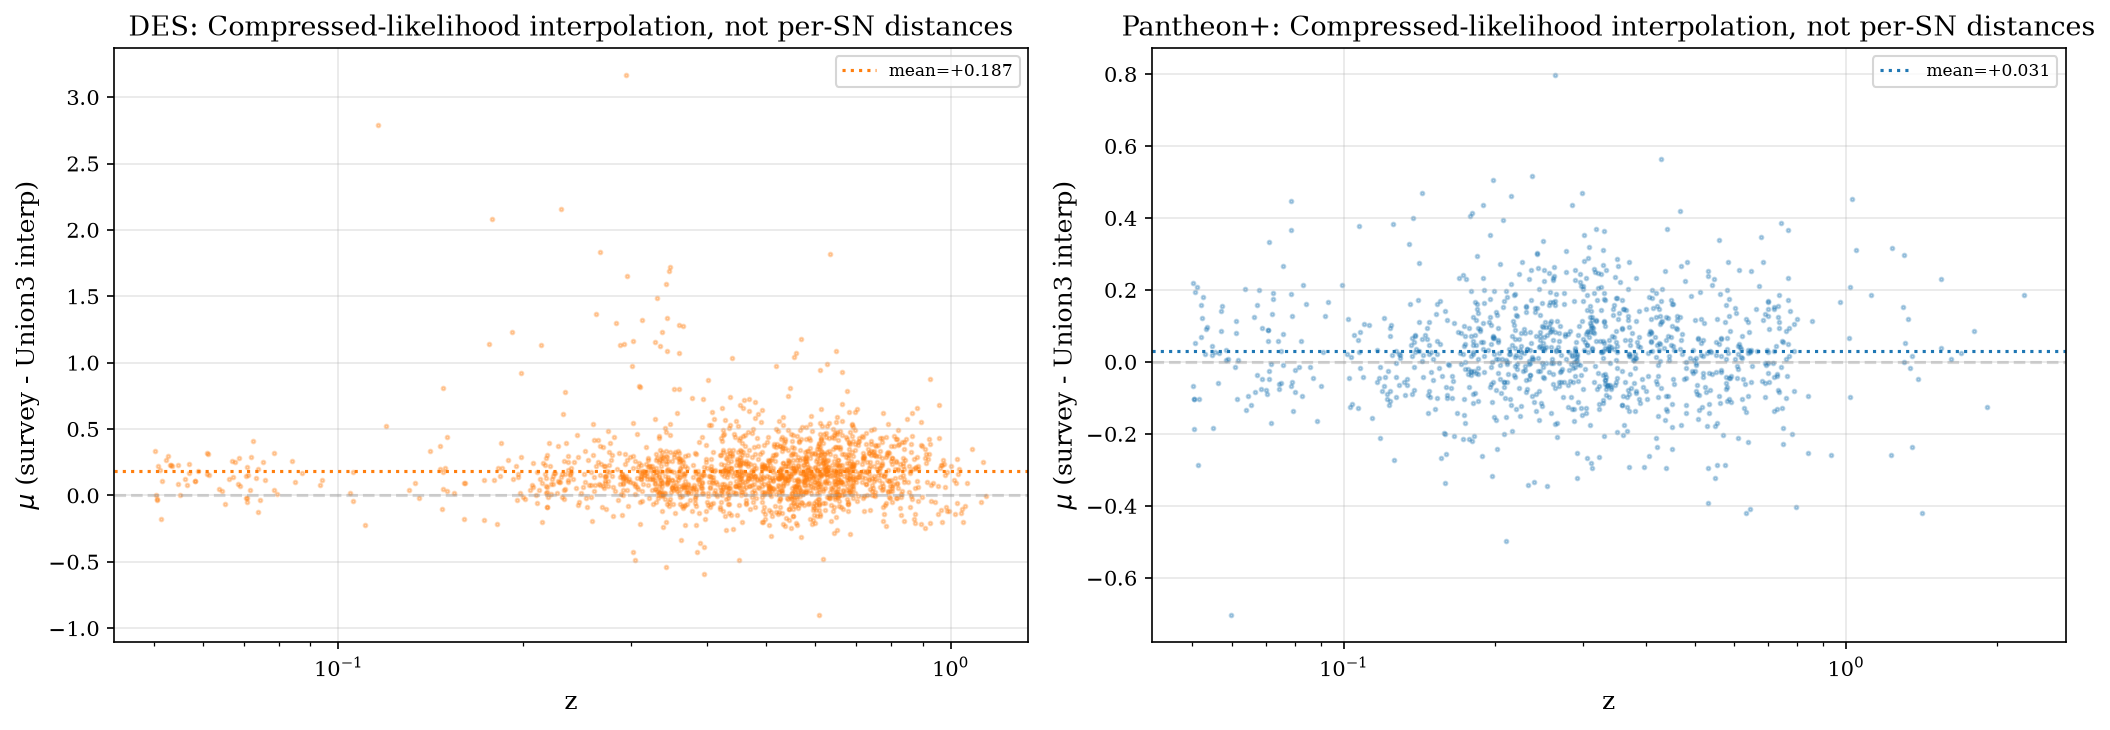

In [120]:
# Interpolate Union3 compressed curve to SN redshifts
# z_pad = np.concatenate(([0.0], z_nodes))
# mu_pad = np.concatenate(([33.0], mu_binned))
mu_interp = interp1d(z_nodes, mu_binned, kind="quadratic", bounds_error=False, fill_value=np.nan)

# DES
des_sn = des_records[["z", "MU"]].dropna().copy()
des_sn["mu_u3_interp"] = mu_interp(des_sn["z"].values)
des_sn["delta"] = des_sn["MU"] - des_sn["mu_u3_interp"]

# Pantheon+
pan_sn = pan_dedup[["zHD", "MU_SH0ES"]].dropna().copy()
pan_sn = pan_sn.rename(columns={"zHD": "z", "MU_SH0ES": "mu"})
pan_sn["mu_u3_interp"] = mu_interp(pan_sn["z"].values)
pan_sn["delta"] = pan_sn["mu"] - pan_sn["mu_u3_interp"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, surv, c in [
    (axes[0], des_sn, "DES", C_DES),
    (axes[1], pan_sn, "Pantheon+", C_PAN),
]:
    ax.axhline(0, color="gray", ls="--", alpha=0.3)
    ax.scatter(df["z"], df["delta"], s=3, alpha=0.3, color=c, rasterized=True)
    mn = np.mean(df["delta"])
    ax.axhline(mn, color=c, ls=":", lw=1.5, label=f"mean={mn:+.3f}")
    ax.set_xscale("log")
    ax.set_xlabel("z")
    ax.set_ylabel(r"$\mu$ (survey - Union3 interp)")
    ax.set_title(f"{surv}: Compressed-likelihood interpolation, not per-SN distances")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Section 5: Tripp vs Union3

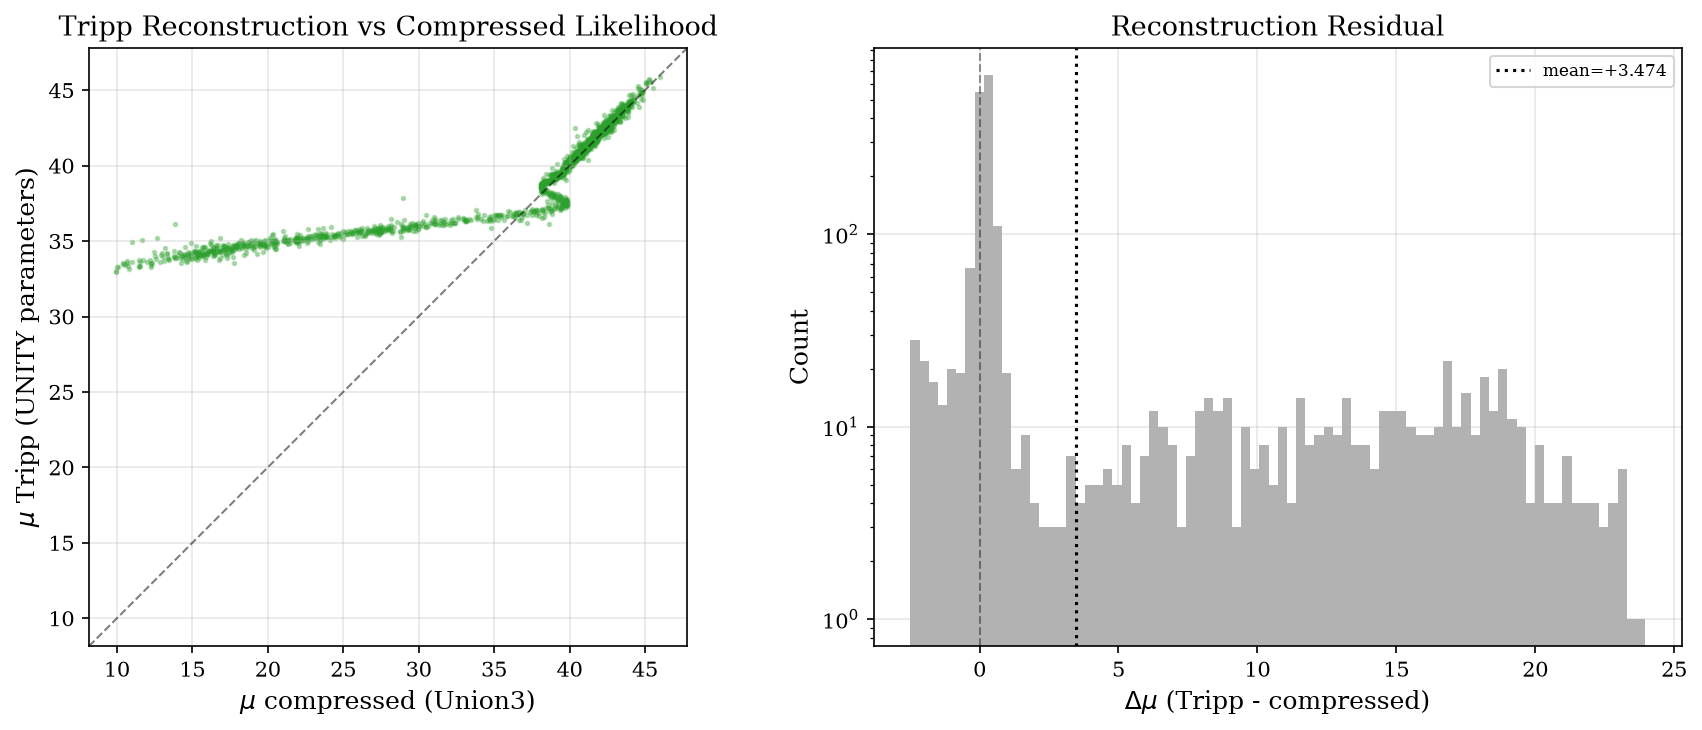

TRIPP RECONSTRUCTION OF UNION3 COMPRESSED LIKELIHOOD
  N = 2087
  <dmu> = +3.4742 mag
  RMS   = 6.3996 mag


In [80]:
# Published UNITY1.5 posterior medians (Rubin+2023)
ALPHA_U3 = 0.168
BETA_U3 = 2.6
MB_U3 = -19.10
DELTA_U3 = 0.031

# Tripp + mass reconstruction
p_high = metadata["p_high_mass"]
mu_tripp = (sn_data["mB_list"] - MB_U3
            + ALPHA_U3 * sn_data["x1_list"]
            - BETA_U3 * sn_data["c_list"]
            + DELTA_U3 * p_high)

# Compressed mu at SN redshifts
z_pad = np.concatenate(([0.0], z_nodes))
mu_pad = np.concatenate(([0.0], mu_binned))
mu_compressed = interp1d(z_pad, mu_pad, kind="quadratic")(sn_data["z_helio_list"])

delta_mu = mu_tripp - mu_compressed

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.scatter(mu_compressed, mu_tripp, s=3, alpha=0.3, color=C_U3, rasterized=True)
lim = [min(mu_compressed.min(), mu_tripp.min()),
       max(mu_compressed.max(), mu_tripp.max())]
pad = 0.05 * (lim[1] - lim[0]); lim = [lim[0] - pad, lim[1] + pad]
ax.plot(lim, lim, "k--", lw=1, alpha=0.5)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel(r"$\mu$ compressed (Union3)")
ax.set_ylabel(r"$\mu$ Tripp (UNITY parameters)")
ax.set_title("Tripp Reconstruction vs Compressed Likelihood")
ax.set_aspect("equal")

ax = axes[1]
ax.hist(delta_mu, bins=80, color="gray", alpha=0.6, edgecolor="none")
ax.axvline(0, color="k", ls="--", lw=1, alpha=0.4)
ax.axvline(np.mean(delta_mu), color="k", ls=":", lw=1.5,
           label=f"mean={np.mean(delta_mu):+.3f}")
ax.set_xlabel(r"$\Delta\mu$ (Tripp - compressed)")
ax.set_ylabel("Count")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.set_title("Reconstruction Residual")

plt.tight_layout()
plt.show()

print("TRIPP RECONSTRUCTION OF UNION3 COMPRESSED LIKELIHOOD")
print("=" * 55)
print(f"  N = {len(delta_mu)}")
print(f"  <dmu> = {np.mean(delta_mu):+.4f} mag")
print(f"  RMS   = {np.std(delta_mu):.4f} mag")


## Section 6: Cosmology

In [81]:
# Load Pantheon+ covariance
print("Loading Pantheon+ covariance...")
pan_path = DATA / "pantheon/DataRelease/Pantheon+_Data/4_DISTANCES_AND_COVAR"
pan_data = pd.read_csv(pan_path / "Pantheon+SH0ES.dat", sep=r"\s+", comment="#")
with open(pan_path / "Pantheon+SH0ES_STAT+SYS.cov") as f:
    N_pan = int(f.readline())
cov_pan = np.loadtxt(pan_path / "Pantheon+SH0ES_STAT+SYS.cov", skiprows=1)
cov_pan = cov_pan.reshape(N_pan, N_pan)
evals = np.linalg.eigvalsh(cov_pan)
print(f"  Pantheon+ cov: min(eig)={evals.min():.6e}, max(eig)={evals.max():.6e}, cond={evals.max()/evals.min():.1e}")

# Load DES inverse covariance
print("Loading DES covariance...")
des_npz = np.load(DATA / "des/DES-SN5YR/4_DISTANCES_COVMAT/STAT+SYS.npz")
N_des = des_npz["nsn"].item()
inv_cov_des = np.zeros((N_des, N_des))
inv_cov_des[np.triu_indices(N_des)] = des_npz["cov"]
inv_cov_des[np.tril_indices(N_des, -1)] = inv_cov_des.T[np.tril_indices(N_des, -1)]
evals = np.linalg.eigvalsh(inv_cov_des)
print(f"  DES inverse cov: min(eig)={evals.min():.6e}, max(eig)={evals.max():.6e}")

# Union3
evals = np.linalg.eigvalsh(icov_u3)
print(f"  Union3 inverse cov: min(eig)={evals.min():.6e}, max(eig)={evals.max():.6e}")

print("Done.")


Loading Pantheon+ covariance...
  Pantheon+ cov: min(eig)=8.027817e-04, max(eig)=2.523706e+00, cond=3.1e+03
Loading DES covariance...
  DES inverse cov: min(eig)=4.565499e-06, max(eig)=2.718407e+02
  Union3 inverse cov: min(eig)=5.121125e+00, max(eig)=7.026188e+03
Done.


In [82]:
# Apply selection cuts and subset covariances

# Pantheon+
pan_mask = (pan_data["zHD"] > 0.01) & (pan_data["IS_CALIBRATOR"] == 0)
pan_idx = np.where(pan_mask)[0]
pan_z = pan_data.loc[pan_mask, "zHD"].values.astype(float)
pan_mu = pan_data.loc[pan_mask, "MU_SH0ES"].values.astype(float)
cov_pan_sel = cov_pan[np.ix_(pan_idx, pan_idx)]
inv_cov_pan = np.linalg.inv(cov_pan_sel)
print(f"Pantheon+: {len(pan_z)} SNe after cuts")

# DES (load HD CSV directly for correct covariance ordering)
des_hd = pd.read_csv(DATA / "des/DES-SN5YR/4_DISTANCES_COVMAT/DES-Dovekie_HD.csv", sep=r"\s+", comment="#")
des_z_all = des_hd["zHD"].values.astype(float)
des_mu_all = des_hd["MU"].values.astype(float)
des_mask = des_z_all > 0.01
des_idx = np.where(des_mask)[0]
des_z = des_z_all[des_mask]
des_mu = des_mu_all[des_mask]
inv_cov_des_sel = inv_cov_des[np.ix_(des_idx, des_idx)]
print(f"DES: {len(des_z)} SNe after cuts")

# Union3 (22 nodes, all z > 0.01)
u3_z = z_nodes
u3_mu = mu_binned
# icov_u3 is already loaded as inverse covariance
print(f"Union3: {len(u3_z)} nodes")


Pantheon+: 1580 SNe after cuts
DES: 1820 SNe after cuts
Union3: 22 nodes


In [83]:
def chi2_marg(params, z, mu, Cinv):
    Om = params[0]
    if Om <= 0.001 or Om >= 0.999:
        return 1e10
    model = FlatLambdaCDM(H0=70, Om0=Om)
    mu_model = model.distmod(z).value
    delta = mu - mu_model
    ones = np.ones_like(delta)
    a = delta @ Cinv @ delta
    b = delta @ Cinv @ ones
    c = ones @ Cinv @ ones
    return a - b**2 / c

print("FLAT LCDM FITS (M/H0 marginalized)")
print("=" * 55)
print(f"  {'Survey':12s} {'Om_best':>8s} {'chi2_min':>9s} {'dof':>5s}")
print("  " + "-" * 35)

flat_results = {}
for label, z, mu, Cinv in [
    ("Pantheon+", pan_z, pan_mu, inv_cov_pan),
    ("DES", des_z, des_mu, inv_cov_des_sel),
    ("Union3", u3_z, u3_mu, icov_u3),
]:
    result = optimize.minimize(chi2_marg, x0=[0.3], args=(z, mu, Cinv),
                                bounds=[(0.01, 0.99)], method="L-BFGS-B")
    Om_best = result.x[0]
    chi2_min = result.fun
    dof = len(z) - 1
    flat_results[label] = {"Om": Om_best, "chi2": chi2_min, "dof": dof}
    print(f"  {label:12s} {Om_best:>8.4f} {chi2_min:>9.2f} {dof:>5d}")


FLAT LCDM FITS (M/H0 marginalized)
  Survey        Om_best  chi2_min   dof
  -----------------------------------
  Pantheon+      0.3316   1387.10  1579
  DES            0.3287   1631.77  1819
  Union3         0.3559     23.96    21


In [88]:
from astropy.cosmology import LambdaCDM
from scipy import optimize
import numpy as np

# -----------------------------
# Robust χ² function
# -----------------------------
def chi2_nonflat_marg(params, z, mu, Cinv):
    Om, Ode = params

    if Om <= 0.001 or Om >= 0.999:
        return 1e10

    if Ode <= 0.001 or Ode >= 1.999:
        return 1e10

    try:
        model = LambdaCDM(H0=70, Om0=float(Om), Ode0=float(Ode))
        mu_model = model.distmod(z).value

        if not np.all(np.isfinite(mu_model)):
            return 1e10

        delta = mu - mu_model

        ones = np.ones_like(delta)

        a = delta @ Cinv @ delta
        b = delta @ Cinv @ ones
        c = ones @ Cinv @ ones

        chi2 = a - b**2 / c

        if not np.isfinite(chi2):
            return 1e10

        return float(chi2)

    except Exception:
        return 1e10


# -----------------------------
# Validation tests
# -----------------------------
starts = [
    [0.2, 0.2],
    [0.3, 0.7],
    [0.8, 0.2],
    [0.5, 1.5]
]

datasets = [
    ("Pantheon+", pan_z, pan_mu, inv_cov_pan),
    ("DES", des_z, des_mu, inv_cov_des_sel),
    ("Union3", u3_z, u3_mu, icov_u3),
]

print("=" * 80)
print("NON-FLAT LCDM VALIDATION")
print("=" * 80)

for label, z, mu, Cinv in datasets:

    print(f"\n\n{label}")
    print("-" * 60)

    # covariance sanity check
    cov = np.linalg.inv(Cinv)
    eig = np.linalg.eigvalsh(cov)

    print(
        f"Covariance eigenvalues: "
        f"min={eig.min():.3e}, "
        f"max={eig.max():.3e}"
    )

    if eig.min() <= 0:
        print("WARNING: covariance not positive definite")

    best_result = None

    for start in starts:

        result = optimize.minimize(
            chi2_nonflat_marg,
            x0=start,
            args=(z, mu, Cinv),
            bounds=[(0.01, 0.99), (0.01, 1.99)],
            method="L-BFGS-B"
        )

        print(
            f"start={start}  "
            f"success={result.success}  "
            f"Om={result.x[0]:.4f}  "
            f"Ode={result.x[1]:.4f}  "
            f"chi2={result.fun:.2f}"
        )

        if result.success:
            best_result = result

    if best_result is None:
        print("No successful minimization.")
        continue

    Om_best, Ode_best = best_result.x
    chi2_min = best_result.fun

    dof = len(z) - 3
    redchi2 = chi2_min / dof

    print("\nBest fit:")
    print(f"Om        = {Om_best:.4f}")
    print(f"Ode       = {Ode_best:.4f}")
    print(f"chi2_min  = {chi2_min:.2f}")
    print(f"dof       = {dof}")
    print(f"chi2/dof  = {redchi2:.3f}")

    # Local minimum test
    chi2_shift = chi2_nonflat_marg(
        [min(0.99, Om_best + 0.05), Ode_best],
        z, mu, Cinv
    )

    print(
        f"Δχ²(+0.05 in Ωm) = "
        f"{chi2_shift - chi2_min:.3f}"
    )

    # Einstein–de Sitter test
    chi2_eds = chi2_nonflat_marg(
        [0.999, 0.001],
        z, mu, Cinv
    )

    print(
        f"χ²(EdS)   = {chi2_eds:.2f}"
    )

    print(
        f"Δχ²(EdS-best) = "
        f"{chi2_eds - chi2_min:.2f}"
    )

NON-FLAT LCDM VALIDATION


Pantheon+
------------------------------------------------------------
Covariance eigenvalues: min=5.196e-03, max=2.391e+00
start=[0.2, 0.2]  success=True  Om=0.3002  Ode=0.6202  chi2=1386.72
start=[0.3, 0.7]  success=True  Om=0.3002  Ode=0.6202  chi2=1386.72
start=[0.8, 0.2]  success=True  Om=0.3002  Ode=0.6202  chi2=1386.72
start=[0.5, 1.5]  success=True  Om=0.3002  Ode=0.6202  chi2=1386.72

Best fit:
Om        = 0.3002
Ode       = 0.6202
chi2_min  = 1386.72
dof       = 1577
chi2/dof  = 0.879
Δχ²(+0.05 in Ωm) = 2.810
χ²(EdS)   = 10000000000.00
Δχ²(EdS-best) = 9999998613.28


DES
------------------------------------------------------------
Covariance eigenvalues: min=3.679e-03, max=2.190e+05
start=[0.2, 0.2]  success=True  Om=0.2858  Ode=0.5998  chi2=1631.17
start=[0.3, 0.7]  success=True  Om=0.2858  Ode=0.5998  chi2=1631.17
start=[0.8, 0.2]  success=True  Om=0.2858  Ode=0.5998  chi2=1631.17
start=[0.5, 1.5]  success=True  Om=0.2858  Ode=0.5998  chi2=1631.17

In [90]:
def chi2_nonflat_marg(params, z, mu, Cinv):
    # Marginalized chi2 for non-flat LCDM
    Om, Ode = params
    if Om <= 0.001 or Om >= 0.999 or Ode <= 0.001 or Ode >= 1.999:
        return 1e10
    if Om + Ode > 2.5:
        return 1e10
    model = LambdaCDM(H0=70, Om0=Om, Ode0=Ode)
    mu_model = model.distmod(z).value
    delta = mu - mu_model
    ones = np.ones_like(delta)
    a = delta @ Cinv @ delta
    b = delta @ Cinv @ ones
    c = ones @ Cinv @ ones
    return a - b**2 / c

print("NON-FLAT LCDM FITS (M/H0 marginalized)")
print("=" * 55)
print(f"  {'Survey':12s} {'Om':>8s} {'Ode':>8s} {'chi2_min':>9s} {'dof':>5s}")
print("  " + "-" * 44)



nf_results = {}
for label, z, mu, Cinv in [
    ("Pantheon+", pan_z, pan_mu, inv_cov_pan),
    ("DES", des_z, des_mu, inv_cov_des_sel),
    ("Union3", u3_z, u3_mu, icov_u3),
]:
    result = optimize.minimize(chi2_nonflat_marg, x0=[0.3, 0.7],
                                args=(z, mu, Cinv),
                                bounds=[(0.01, 0.99), (0.01, 1.99)],
                                method="L-BFGS-B")
    Om_best, Ode_best = result.x
    chi2_min = result.fun
    dof = len(z) - 2
    nf_results[label] = {"Om": Om_best, "Ode": Ode_best, "chi2": chi2_min, "dof": dof}
    print(f"  {label:12s} {Om_best:>8.4f} {Ode_best:>8.4f} {chi2_min:>9.2f} {dof:>5d}")


NON-FLAT LCDM FITS (M/H0 marginalized)
  Survey             Om      Ode  chi2_min   dof
  --------------------------------------------
  Pantheon+      0.3002   0.6202   1386.72  1578
  DES            0.2858   0.5998   1631.17  1818
  Union3         0.2876   0.5092     22.56    20


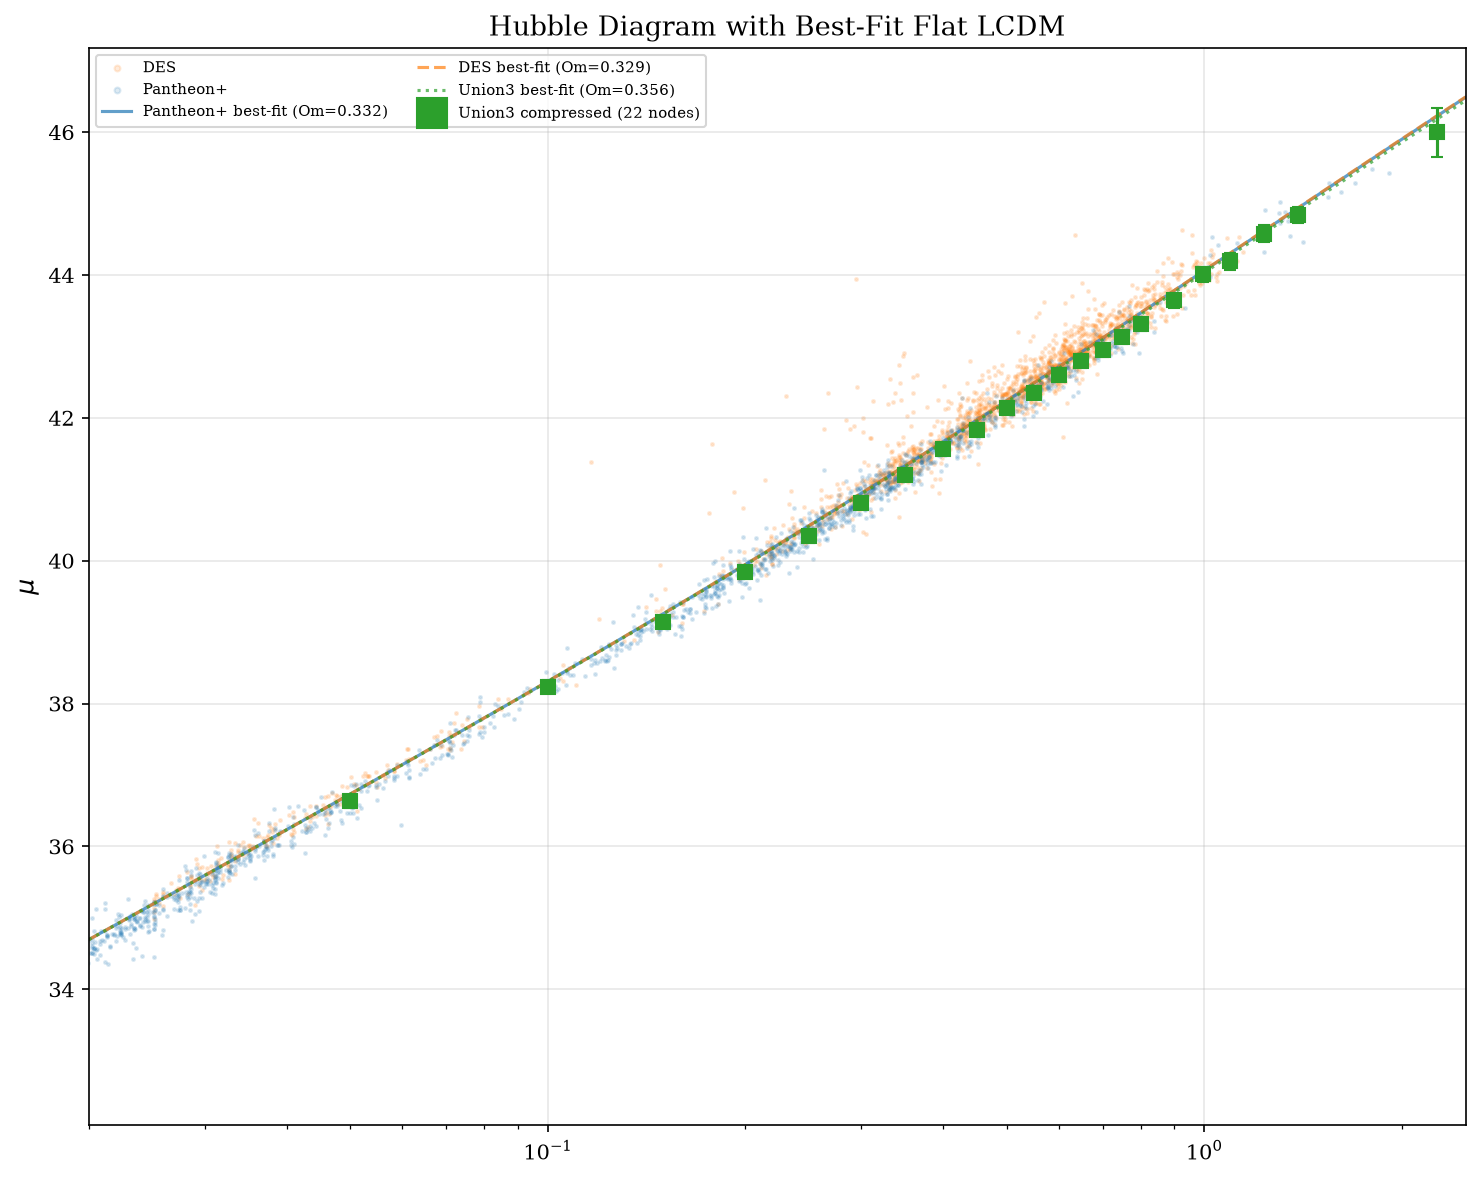

In [97]:
# Hubble diagram with best-fit flat LCDM
fig, ax1 = plt.subplots(figsize=(10, 8),)

z_curve = np.logspace(np.log10(0.02), np.log10(2.5), 300)

# Upper panel: Hubble diagram
ax1.errorbar(z_nodes, mu_binned, yerr=mu_binned_err, fmt="s", color=C_U3,
             ms=7, capsize=3, label="Union3 compressed (22 nodes)", zorder=5)
ax1.scatter(des_z, des_mu, s=2, alpha=0.15, color=C_DES, label="DES", rasterized=True)
ax1.scatter(pan_z, pan_mu, s=2, alpha=0.15, color=C_PAN, label="Pantheon+", rasterized=True)

for surv, c, ls in [("Pantheon+", C_PAN, "-"), ("DES", C_DES, "--"), ("Union3", C_U3, ":")]:
    Om = flat_results[surv]["Om"]
    model = FlatLambdaCDM(H0=70, Om0=Om)
    mu_m = model.distmod(z_curve).value
    ax1.plot(z_curve, mu_m, color=c, ls=ls, lw=1.5, alpha=0.7,
             label=f"{surv} best-fit (Om={Om:.3f})")

ax1.set_ylabel(r"$\mu$")
ax1.set_title("Hubble Diagram with Best-Fit Flat LCDM")
ax1.set_xscale("log")
ax1.legend(fontsize=7, markerscale=2, ncol=2)
ax1.set_xlim(0.02, 2.5)

# Lower panel: residuals relative to Einstein-de Sitter (Om=1, Ode=0)
# eds = LambdaCDM(H0=70, Om0=1.0, Ode0=0.0)
# mu_eds_nodes = eds.distmod(z_nodes).value
# mu_eds_des = eds.distmod(des_z).value
# mu_eds_pan = eds.distmod(pan_z).value

# ax2.axhline(0, color="gray", ls="--", alpha=0.3)
# ax2.errorbar(z_nodes, mu_binned - mu_eds_nodes, yerr=mu_binned_err,
#              fmt="s", color=C_U3, ms=5, capsize=2, label="Union3", zorder=5)
# ax2.scatter(des_z, des_mu - mu_eds_des, s=1, alpha=0.15, color=C_DES, rasterized=True)
# ax2.scatter(pan_z, pan_mu - mu_eds_pan, s=1, alpha=0.15, color=C_PAN, rasterized=True)
# ax2.set_xlabel("Redshift z")
# ax2.set_ylabel(r"$\mu - \mu_{\rm EdS}$")
# ax2.set_title("Residuals Relative to Einstein-de Sitter")
# ax2.set_xscale("log")
# ax2.legend(fontsize=8, markerscale=2)
# ax2.set_xlim(0.02, 2.5)

plt.tight_layout()
plt.show()


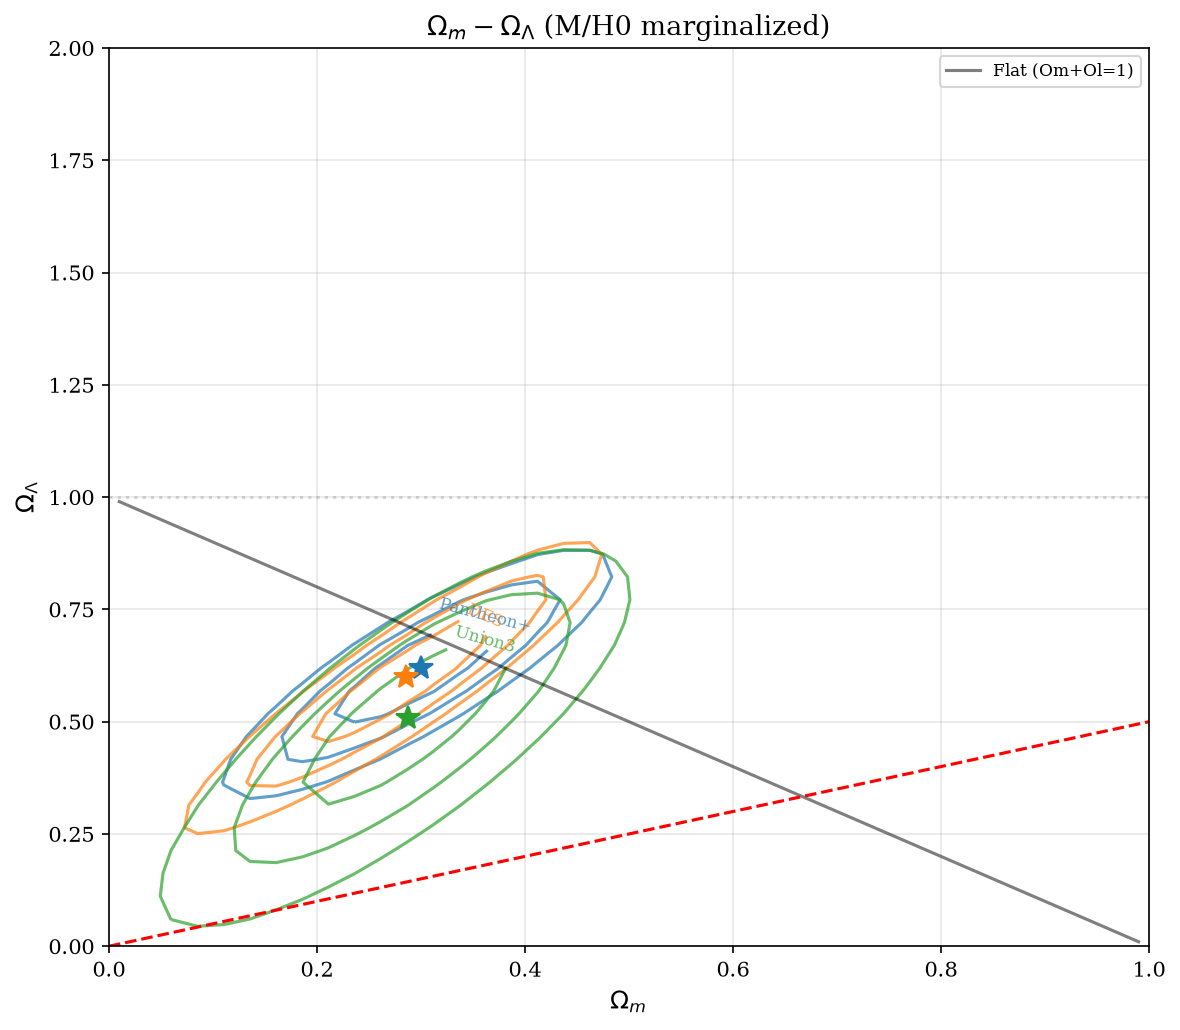

In [92]:
def chi2_grid_val(Om, Ode, z, mu, Cinv):
    # Marginalized chi2 for grid evaluation
    model = LambdaCDM(H0=70, Om0=Om, Ode0=Ode)
    mu_model = model.distmod(z).value
    delta = mu - mu_model
    ones = np.ones_like(delta)
    a = delta @ Cinv @ delta
    b = delta @ Cinv @ ones
    c = ones @ Cinv @ ones
    return a - b**2 / c

fig, ax = plt.subplots(figsize=(8, 7))

Om_grid = np.linspace(0.01, 0.99, 40)
Ode_grid = np.linspace(0.01, 1.99, 40)

survey_data = [
    ("Pantheon+", pan_z, pan_mu, inv_cov_pan, C_PAN, nf_results["Pantheon+"]),
    ("DES", des_z, des_mu, inv_cov_des_sel, C_DES, nf_results["DES"]),
    ("Union3", u3_z, u3_mu, icov_u3, C_U3, nf_results["Union3"]),
]

for label, z, mu, Cinv, color, bf in survey_data:
    chi2_grid = np.full((len(Om_grid), len(Ode_grid)), np.nan)
    for i, Om in enumerate(Om_grid):
        for j, Ode in enumerate(Ode_grid):
            try:
                chi2_grid[i, j] = chi2_grid_val(Om, Ode, z, mu, Cinv)
            except Exception:
                continue

    chi2_min = np.nanmin(chi2_grid)
    dchi2 = chi2_grid - chi2_min
    levels = [2.30, 6.18, 11.83]
    cs = ax.contour(Om_grid, Ode_grid, dchi2.T, levels=levels,
                    colors=[color], linewidths=1.5, alpha=0.7)
    ax.plot(bf["Om"], bf["Ode"], marker="*", color=color, ms=12, zorder=10)
    ax.clabel(cs, levels=[2.30], fmt={2.30: label}, fontsize=8, colors=color)

om_line = np.linspace(0.01, 0.99, 100)
ax.plot(om_line, 1 - om_line, "k-", lw=1.5, alpha=0.5, label="Flat (Om+Ol=1)")
ax.axhline(1.0, color="gray", ls=":", alpha=0.3)
ax.set_xlabel(r"$\Omega_m$")
ax.set_ylabel(r"$\Omega_\Lambda$")
ax.set_title(r"$\Omega_m - \Omega_\Lambda$ (M/H0 marginalized)")
ax.legend(fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 2)

om = np.linspace(0,1,200)
ax.plot(om, 0.5*om, 'r--', label='q0=0')

plt.tight_layout()
plt.show()


## Results

In [ ]:
results = [
    ("S2: dmB (Pan - U3)", f"{np.mean(xd[xd['pair']=='Pantheon+_vs_Union3']['dmB'].dropna()):+.4f} +/- {np.std(xd[xd['pair']=='Pantheon+_vs_Union3']['dmB'].dropna()):.4f} mag", "Matched SALT2 mB offset"),
    ("S2: dmB (DES - U3)", f"{np.mean(xd[xd['pair']=='DES_vs_Union3']['dmB'].dropna()):+.4f} +/- {np.std(xd[xd['pair']=='DES_vs_Union3']['dmB'].dropna()):.4f} mag", "Matched SALT2 mB offset"),
    ("S2: dmB (DES - Pan)", f"{np.mean(xd[xd['pair']=='DES_vs_Pantheon+']['dmB'].dropna()):+.4f} +/- {np.std(xd[xd['pair']=='DES_vs_Pantheon+']['dmB'].dropna()):.4f} mag", "Matched SALT2 mB offset"),
]

results.extend([
    ("S3: dmu* (Pan - U3)", f"{np.mean(pair['dmu_star']):+.4f} +/- {np.std(pair['dmu_star']):.4f} mag", "Offset after per-survey Tripp standardization"),
])

results.extend([
    ("S4: mu DES - U3 (22 nodes)", f"{np.nanmean(delta_des):+.4f} +/- {np.nanstd(delta_des):.4f} mag", "Published distance offset at 22 nodes"),
    ("S4: mu Pan - U3 (22 nodes)", f"{np.nanmean(delta_pan):+.4f} +/- {np.nanstd(delta_pan):.4f} mag", "Published distance offset at 22 nodes"),
])

results.extend([
    ("S5: Tripp - compressed (U3)", f"{np.mean(delta_mu):+.4f} +/- {np.std(delta_mu):.4f} mag", "Tripp reconstruction disagreement"),
])

results.extend([
    ("S6: Om flat (Union3)", f"{flat_results['Union3']['Om']:.4f}", "Flat LCDM constraint from 22 nodes"),
    ("S6: Om flat (DES)", f"{flat_results['DES']['Om']:.4f}", "Flat LCDM constraint from 1820 SNe"),
    ("S6: Om flat (Pantheon+)", f"{flat_results['Pantheon+']['Om']:.4f}", "Flat LCDM constraint from 1701 SNe"),
    ("S6: Om nf (Union3)", f"{nf_results['Union3']['Om']:.4f}, Ode={nf_results['Union3']['Ode']:.4f}", "Non-flat LCDM"),
    ("S6: Om nf (DES)", f"{nf_results['DES']['Om']:.4f}, Ode={nf_results['DES']['Ode']:.4f}", "Non-flat LCDM"),
    ("S6: Om nf (Pantheon+)", f"{nf_results['Pantheon+']['Om']:.4f}, Ode={nf_results['Pantheon+']['Ode']:.4f}", "Non-flat LCDM"),
])

print("SUMMARY TABLE")
print("=" * 90)
print(f"  {'Analysis':35s} {'Result':40s} {'Interpretation'}")
print("  " + "-" * 88)
for analysis, result, interp in results:
    print(f"  {analysis:35s} {result:40s} {interp}")


SUMMARY TABLE
  Analysis                            Result                                   Interpretation
  ----------------------------------------------------------------------------------------
  S2: dmB (Pan - U3)                  -0.2826 +/- 0.0339 mag                   Matched SALT2 mB offset
  S2: dmB (DES - U3)                  -0.2823 +/- 0.0385 mag                   Matched SALT2 mB offset
  S2: dmB (DES - Pan)                 -0.0122 +/- 0.0367 mag                   Matched SALT2 mB offset
  S3: dmu* (Pan - U3)                 +0.0137 +/- 0.0581 mag                   Offset after per-survey Tripp standardization
  S4: mu DES - U3 (22 nodes)          +0.1711 +/- 0.1454 mag                   Published distance offset at 22 nodes
  S4: mu Pan - U3 (22 nodes)          +0.0256 +/- 0.1216 mag                   Published distance offset at 22 nodes
  S5: Tripp - compressed (U3)         +3.4766 +/- 6.3908 mag                   Tripp reconstruction disagreement
  S6: Om flat (Union